In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
HERE = %pwd
sys.path.append(os.path.dirname(HERE))

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import numpy as np
import pandas as pd
import copy
import pickle
import hashlib
from tqdm import tqdm
from collections import defaultdict

In [2]:
from src import utils
rng = utils.set_seed()

dir_parent = utils.dir_parent
version_exp = utils.version_exp
dir_workspace = f"{dir_parent}/research/TFCSR"

In [3]:
dir_result = f"{dir_workspace}/results"
dir_figs = f"{dir_workspace}/figs"
dir_cache = f"{dir_workspace}/score_data"
for d in [dir_result, dir_figs, dir_cache]:
    os.makedirs(d, exist_ok=True)

# Config

In [4]:
data_names = ["MovieLens", "Job"] + [f"ARD_{a}" for a in [
    "CDs_and_Vinyl", "Movies_and_TV", "Toys_and_Games", "Sports_and_Outdoors"
]]
N_icl = [1, 3, 5]

model_names_emb = [
    "princeton-nlp/sup-simcse-roberta-large",
    "answerdotai/ModernBERT-large",
    "FacebookAI/roberta-large",
    "intfloat/multilingual-e5-large",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-modernbert-base",
    "Qwen/Qwen3-Embedding-0.6B",
    "Qwen/Qwen3-Embedding-8B",
    "nvidia/llama-embed-nemotron-8b"
]
model_names_reranker = [
    "BM25",
    "BAAI/bge-reranker-v2-m3",
    "Alibaba-NLP/gte-reranker-modernbert-base",
    "Qwen/Qwen3-Reranker-0.6B",
    "Qwen/Qwen3-Reranker-8B",
]
model_names_llm = [
    "us.meta.llama3-3-70b-instruct-v1:0",
    "qwen.qwen3-235b-a22b-2507-v1:0",
    "gpt-4.1-mini-2025-04-14",
    "gpt-5.1-2025-11-13_reasoning_none",
    "gpt-5.4-2026-03-05_reasoning_none",
    "us.anthropic.claude-sonnet-4-5-20250929-v1:0",
]

candidate_size = 10
at_K = 5
p_value = 1e-3
model_name_base = "[E] SimCSE:::default"

# Load

In [5]:
from src.scorer import Scorer
from src.result_loader import Loader

def _unit_cache_path(version_exp, n_icl, flag_NER, candidate_size, at_K, data_name, model_name):
    ner = "ner" if flag_NER else "orig"
    nicl_str = "-".join(str(n) for n in sorted(n_icl))
    safe_model = model_name.replace("/", "__")
    return (f"{dir_cache}/v{version_exp}_{ner}_c{candidate_size}_k{at_K}"
            f"_nicl{nicl_str}/{data_name}/{safe_model}.pickle")

def load_with_cache(scorer, loader, data_names, model_names_emb, model_names_reranker, model_names_llm):
    from src.data_loader import Loader as DataLoader

    ddict_score = defaultdict(dict)
    ddict_log = defaultdict(dict)

    all_models = (
        [(m, "emb") for m in model_names_emb]
        + [(m, "reranker") for m in model_names_reranker]
        + [(m, "llm") for m in model_names_llm]
    )

    for data_name in data_names:
        data_name_paper = loader.rename_for_paper(data_name)
        print("==" * 20, data_name_paper, "==" * 20)

        data_loader = None  # lazily created only when needed

        for model_name_raw, model_type in tqdm(all_models, desc="Models"):
            model_name_paper = loader.rename_for_paper(model_name_raw)
            cache_path = _unit_cache_path(
                loader.version_exp, loader.N_icl, loader.flag_replace_NER,
                scorer.candidate_size, scorer.at_K, data_name, model_name_raw,
            )

            if os.path.exists(cache_path):
                with open(cache_path, "rb") as f:
                    cached = pickle.load(f)
                d_score = cached["score"]
                d_log = cached.get("log")
            else:
                if data_loader is None:
                    data_loader = DataLoader(
                        loader.dir_workspace, loader.version_exp, data_name,
                        N_icl=loader.N_icl, flag_replace_NER=loader.flag_replace_NER,
                        n_users=loader.n_users,
                    )
                    dict_data = data_loader.load_data()

                d_log = None
                if model_type == "emb":
                    d_score = loader._load_emb(data_loader, dict_data, model_name_raw)
                elif model_type == "reranker":
                    d_score = loader._load_reranker(data_loader, dict_data, model_name_raw)
                else:
                    try:
                        d_score, d_log = loader._load_llmreranker(data_loader, dict_data, model_name_raw)
                    except Exception:
                        continue

                os.makedirs(os.path.dirname(cache_path), exist_ok=True)
                with open(cache_path, "wb") as f:
                    pickle.dump({"score": d_score, "log": d_log}, f)
                

            ddict_score[data_name_paper][model_name_paper] = d_score
            if d_log is not None:
                ddict_log[data_name_paper][model_name_paper] = d_log

    # reshape: same logic as Loader.load_all_score
    P = ["profile"] + list(np.concatenate(
        [[f"{a}_{n_icl}-sample" for a in ["separate", "concat"]] for n_icl in loader.N_icl]
    ))
    dict_data_out = {p: defaultdict(dict) for p in P}
    for p in P:
        for data_name, dict_score in ddict_score.items():
            for model_name, d_score in dict_score.items():
                for t, d_ in d_score.items():
                    text_type, inst_type = t.split(":::")
                    if p in text_type:
                        if "profile" in text_type:
                            if data_name == "ML-1M":
                                a = data_name
                            else:
                                a = f"{data_name} ({loader.rename_profile_suffix(text_type.split('_')[1])})"
                        else:
                            a = data_name
                        dict_data_out[p][a][f"{model_name}:::{inst_type}"] = pd.DataFrame(d_)

    print("==" * 20, "Total computation cost in USD", "==" * 20)
    loader._calculate_cost(ddict_log)
    return dict_data_out, ddict_log


In [6]:
# original text
scorer = Scorer(candidate_size=candidate_size, at_K=at_K)
loader = Loader(scorer, dir_workspace, version_exp, N_icl=N_icl, flag_replace_NER=False)
dict_data, ddict_log = load_with_cache(
    scorer, loader, data_names, model_names_emb, model_names_reranker, model_names_llm
)

======================================== ML-1M ========================================


Models: 100%|███████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 157.86it/s]


======================================== Job ========================================


Models: 100%|███████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 224.20it/s]


======================================== Music ========================================


...

======================================== Sports ========================================


Models: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 71.45it/s]


======================================== Total computation cost in USD ========================================


,ML-1M,Job,Music,Movie,Toys,Sports,Sum
[LLM] Llama3.3 (70B),0.9,7.7,2.6,2.6,2.8,2.5,19.0
[LLM] Qwen3-235B-A22B,0.3,2.4,0.8,0.8,0.9,0.8,6.1
[LLM] GPT-4.1 mini,0.5,4.3,1.5,1.5,1.6,1.4,10.7
[LLM] GPT-5.1,1.9,14.1,5.0,5.0,5.2,4.8,36.0
[LLM] GPT-5.4,3.2,27.3,9.4,9.4,10.0,9.1,68.5
[LLM] Sonnet 4.5,7.0,42.7,15.5,17.2,16.7,15.0,114.2


\begin{tabular}{llllllll}
\toprule
 & ML-1M & Job & Music & Movie & Toys & Sports & Sum \\
\midrule
[LLM] Llama3.3 (70B) & $0.9$ & $7.7$ & $2.6$ & $2.6$ & $2.8$ & $2.5$ & $19.0$ \\
[LLM] Qwen3-235B-A22B & $0.3$ & $2.4$ & $0.8$ & $0.8$ & $0.9$ & $0.8$ & $6.1$ \\
[LLM] GPT-4.1 mini & $0.5$ & $4.3$ & $1.5$ & $1.5$ & $1.6$ & $1.4$ & $10.7$ \\
[LLM] GPT-5.1 & $1.9$ & $14.1$ & $5.0$ & $5.0$ & $5.2$ & $4.8$ & $36.0$ \\
[LLM] GPT-5.4 & $3.2$ & $27.3$ & $9.4$ & $9.4$ & $10.0$ & $9.1$ & $68.5$ \\
[LLM] Sonnet 4.5 & $7.0$ & $42.7$ & $15.5$ & $17.2$ & $16.7$ & $15.0$ & $114.2$ \\
\bottomrule
\end{tabular}



In [7]:
# NER-replaced text
loader_NER = Loader(scorer, dir_workspace, version_exp, N_icl=N_icl, flag_replace_NER=True)
dict_data_NER, ddict_log_NER = load_with_cache(
    scorer, loader_NER, data_names, model_names_emb, model_names_reranker, model_names_llm
)

======================================== ML-1M ========================================


Models: 100%|███████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 188.63it/s]


======================================== Job ========================================


Models: 100%|███████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 180.49it/s]


======================================== Music ========================================


...

======================================== Sports ========================================


Models: 100%|███████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 204.11it/s]

======================================== Total computation cost in USD ========================================


,ML-1M,Job,Music,Movie,Toys,Sports,Sum
[LLM] Llama3.3 (70B),0.8,7.7,2.6,2.6,2.8,2.5,19.0
[LLM] Qwen3-235B-A22B,0.3,2.4,0.8,0.8,0.9,0.8,6.0
[LLM] GPT-4.1 mini,0.5,4.3,1.5,1.5,1.6,1.4,10.8
[LLM] GPT-5.1,1.9,14.2,5.1,5.0,5.3,4.8,36.3
[LLM] GPT-5.4,3.2,27.6,9.7,9.6,10.0,9.1,69.2
[LLM] Sonnet 4.5,6.7,44.1,19.0,19.4,18.7,16.2,124.2


\begin{tabular}{llllllll}
\toprule
 & ML-1M & Job & Music & Movie & Toys & Sports & Sum \\
\midrule
[LLM] Llama3.3 (70B) & $0.8$ & $7.7$ & $2.6$ & $2.6$ & $2.8$ & $2.5$ & $19.0$ \\
[LLM] Qwen3-235B-A22B & $0.3$ & $2.4$ & $0.8$ & $0.8$ & $0.9$ & $0.8$ & $6.0$ \\
[LLM] GPT-4.1 mini & $0.5$ & $4.3$ & $1.5$ & $1.5$ & $1.6$ & $1.4$ & $10.8$ \\
[LLM] GPT-5.1 & $1.9$ & $14.2$ & $5.1$ & $5.0$ & $5.3$ & $4.8$ & $36.3$ \\
[LLM] GPT-5.4 & $3.2$ & $27.6$ & $9.7$ & $9.6$ & $10.0$ & $9.1$ & $69.2$ \\
[LLM] Sonnet 4.5 & $6.7$ & $44.1$ & $19.0$ & $19.4$ & $18.7$ & $16.2$ & $124.2$ \\
\bottomrule
\end{tabular}



# Statistics

In [8]:
dict_stat   = loader.add_statistics(dict_data, model_name_base)
ddict_table = {s: loader.reshape_data(dict_stat, s) for s in ["ndcg", "recall"]}

dict_stat_NER   = loader_NER.add_statistics(dict_data_NER, model_name_base)
ddict_table_NER = {s: loader_NER.reshape_data(dict_stat_NER, s) for s in ["ndcg", "recall"]}

Hypothesis Testing: 100%|██████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  3.68it/s]


# Model selection

In [9]:
model_names_selected_encoder = [
    '[E] SimCSE',
    '[E] ME5',
    '[E] BGE-M3',
    '[E] GTE',
    '[E] Qwen3 (0.6B)',
    '[E] Qwen3 (8B)',
    '[E] Nemotron (8B)',
    '[R] BGE-M3',
    '[R] GTE',
    '[R] Qwen3 (0.6B)',
    '[R] Qwen3 (8B)',
]
model_names_selected_llm = [
    '[LLM] GPT-4.1 mini',
    '[LLM] GPT-5.1',
    '[LLM] GPT-5.4',
    '[LLM] Sonnet 4.5',
]
model_names_selected = model_names_selected_encoder + model_names_selected_llm

# Full list used in appendix tables (includes baselines and all LLMs).
model_names_all_encoder = [
    '[E] SimCSE',
    '[E] ModernBERT',
    '[E] RoBERTa',
    '[E] ME5',
    '[E] BGE-M3',
    '[E] GTE',
    '[E] Qwen3 (0.6B)',
    '[E] Qwen3 (8B)',
    '[E] Nemotron (8B)',
    '[R] BM25',
    '[R] BGE-M3',
    '[R] GTE',
    '[R] Qwen3 (0.6B)',
    '[R] Qwen3 (8B)',
]
model_names_all_llm = [
    '[LLM] Llama3.3 (70B)',
    '[LLM] Qwen3-235B-A22B',
    '[LLM] GPT-4.1 mini',
    '[LLM] GPT-5.1',
    '[LLM] GPT-5.4',
    '[LLM] Sonnet 4.5',
]
model_names_all = model_names_all_encoder + model_names_all_llm

# Subset shown in the main NER table (paper Table 4).
model_names_selected_NER = [
    "[E] SimCSE",
    "[E] Qwen3 (8B)",
    "[E] Nemotron (8B)",
    "[R] BM25",
    "[R] GTE",
    "[R] Qwen3 (8B)",
    "[LLM] GPT-5.1",
    "[LLM] GPT-5.4",
    "[LLM] Sonnet 4.5",
]


# Figure style

In [10]:
plt.rcParams.update({
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

FS = dict(
    title=13,
    axis=12,
    tick=11,
    legend=11,
    annot=12,
    annot_small=10,
)

from src.visualizer import plot_ner_impact, plot_mrr_heatmap, plot_concat_vs_separate
from src.figure_data import extract_ner_impact, extract_mrr_heatmap

# Main results

In [11]:
for score_name, dict_table in ddict_table.items():
    print("=="*10, score_name, "=="*10)
    d_ = defaultdict(dict)
    for p, d in dict_table.items():
        if p in ["profile", "separate_1-sample"]:
            df_tex, df_color = loader.to_tex(d, p_value, model_name_base)
            p2 = p.replace("separate_", "").replace("sample", "shot")
            d_["tex"][p2]   = loader.reindex(df_tex)
            d_["color"][p2] = loader.reindex(df_color)

    df_tex = pd.concat(d_["tex"], axis=1)
    display(df_tex)
    df_tex = pd.concat(d_["color"], axis=1) + df_tex
    df_tex = loader.to_two_columns(df_tex)
    print(df_tex.to_latex(escape=False))

==================== ndcg ====================


profile                           \
                                         ML-1M           Job (with-exp)   
[E] SimCSE                             $0.414$                  $0.491$   
[E] ModernBERT                         $0.443$  $0.347^{\triangledown}$   
[E] RoBERTa            $0.353^{\triangledown}$  $0.333^{\triangledown}$   
[E] ME5                                $0.421$              $0.607^{*}$   
[E] BGE-M3                             $0.447$              $0.554^{*}$   
[E] GTE                                $0.402$              $0.545^{*}$   
[E] Qwen3 (0.6B)                       $0.424$              $0.576^{*}$   
[E] Qwen3 (8B)             $\underline{0.449}$              $0.623^{*}$   
[E] Nemotron (8B)             $\textbf{0.450}$              $0.608^{*}$   
[R] BM25               $0.352^{\triangledown}$                  $0.468$   
[R] BGE-M3                             $0.410$              $0.604^{*}$   
[R] GTE                                $0.391$                  $0.506$   
[R] Qwen3 (0.6B)                       $0.430$                  $0.543$   
[R] Qwen3 (8B)                         $0.445$     $\textbf{0.687}^{*}$   
[LLM] Llama3.3 (70B)   $0.355^{\triangledown}$                  $0.439$   
[LLM] Qwen3-235B-A22B                  $0.365$                  $0.467$   
[LLM] GPT-4.1 mini                     $0.402$              $0.570^{*}$   
[LLM] GPT-5.1                          $0.431$              $0.606^{*}$   
[LLM] GPT-5.4                          $0.446$              $0.588^{*}$   
[LLM] Sonnet 4.5                       $0.423$  $\underline{0.630}^{*}$   

                                                                 1-shot  \
                                  Job (no-exp)                    ML-1M   
[E] SimCSE                             $0.444$                  $0.601$   
[E] ModernBERT         $0.340^{\triangledown}$  $0.516^{\triangledown}$   
[E] RoBERTa            $0.328^{\triangledown}$  $0.545^{\triangledown}$   
[E] ME5                            $0.558^{*}$                  $0.594$   
[E] BGE-M3                             $0.484$                  $0.584$   
[E] GTE                            $0.500^{*}$                  $0.571$   
[E] Qwen3 (0.6B)                   $0.495^{*}$                  $0.577$   
[E] Qwen3 (8B)                     $0.520^{*}$                  $0.612$   
[E] Nemotron (8B)                  $0.527^{*}$         $\textbf{0.630}$   
[R] BM25                               $0.399$                  $0.569$   
[R] BGE-M3                $\textbf{0.582}^{*}$  $0.542^{\triangledown}$   
[R] GTE                                $0.471$  $0.343^{\triangledown}$   
[R] Qwen3 (0.6B)                       $0.418$      $\underline{0.614}$   
[R] Qwen3 (8B)         $\underline{0.564}^{*}$                  $0.614$   
[LLM] Llama3.3 (70B)                   $0.398$  $0.481^{\triangledown}$   
[LLM] Qwen3-235B-A22B                  $0.393$  $0.483^{\triangledown}$   
[LLM] GPT-4.1 mini                     $0.466$  $0.522^{\triangledown}$   
[LLM] GPT-5.1                      $0.502^{*}$  $0.519^{\triangledown}$   
[LLM] GPT-5.4                          $0.457$  $0.529^{\triangledown}$   
[LLM] Sonnet 4.5                       $0.491$  $0.546^{\triangledown}$   

                                                                         \
                                           Job                    Music   
[E] SimCSE                             $0.567$                  $0.536$   
[E] ModernBERT         $0.454^{\triangledown}$  $0.431^{\triangledown}$   
[E] RoBERTa            $0.475^{\triangledown}$  $0.457^{\triangledown}$   
[E] ME5                            $0.615^{*}$                  $0.520$   
[E] BGE-M3                             $0.578$                  $0.538$   
[E] GTE                                $0.603$              $0.619^{*}$   
[E] Qwen3 (0.6B)                       $0.590$              $0.593^{*}$   
[E] Qwen3 (8B)                         $0.603$              $0

\begin{tabular}{llllllllll}
\toprule
 & \multicolumn{3}{r}{profile} & \multicolumn{6}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & ML-1M & Job & Music & Movie & Toys & Sports \\
\midrule
E &  SimCSE & $0.414$ & $0.491$ & $0.444$ & $0.601$ & $0.567$ & $0.536$ & $0.557$ & $0.585$ & $0.599$ \\
E &  ModernBERT & \cellcolor{pslow}$0.443$ & \cellcolor{nshigh}$0.347^{\triangledown}$ & \cellcolor{nshigh}$0.340^{\triangledown}$ & \cellcolor{nmiddle}$0.516^{\triangledown}$ & \cellcolor{nhigh}$0.454^{\triangledown}$ & \cellcolor{nhigh}$0.431^{\triangledown}$ & \cellcolor{nhigh}$0.467^{\triangledown}$ & \cellcolor{nmiddle}$0.517^{\triangledown}$ & \cellcolor{nshigh}$0.463^{\triangledown}$ \\
E &  RoBERTa & \cellcolor{nmiddle}$0.353^{\triangledown}$ & \cellcolor{nshigh}$0.333^{\triangledown}$ & \cellcolor{nshigh}$0.328^{\triangledown}$ & \cellcolor{nlow}$0.545^{\triangledown}$ & \cellcolor{nhigh}$0.475^{\triangledown}$ & \cellcolor{nmiddle}$0.457^{\triangledown}$ & \cellcolor{nslow}$0.5

profile                           \
                                     ML-1M           Job (with-exp)   
[E] SimCSE                         $0.554$                  $0.612$   
[E] ModernBERT                     $0.573$  $0.472^{\triangledown}$   
[E] RoBERTa                        $0.494$  $0.467^{\triangledown}$   
[E] ME5                            $0.565$  $\underline{0.722}^{*}$   
[E] BGE-M3             $\underline{0.592}$                  $0.667$   
[E] GTE                            $0.546$              $0.675^{*}$   
[E] Qwen3 (0.6B)                   $0.588$              $0.689^{*}$   
[E] Qwen3 (8B)            $\textbf{0.595}$              $0.722^{*}$   
[E] Nemotron (8B)                  $0.591$              $0.715^{*}$   
[R] BM25                           $0.493$                  $0.603$   
[R] BGE-M3                         $0.574$              $0.702^{*}$   
[R] GTE                            $0.528$                  $0.635$   
[R] Qwen3 (0.6B)                   $0.581$                  $0.636$   
[R] Qwen3 (8B)                     $0.581$     $\textbf{0.791}^{*}$   
[LLM] Llama3.3 (70B)               $0.526$  $0.532^{\triangledown}$   
[LLM] Qwen3-235B-A22B              $0.516$  $0.524^{\triangledown}$   
[LLM] GPT-4.1 mini                 $0.539$                  $0.640$   
[LLM] GPT-5.1                      $0.548$                  $0.663$   
[LLM] GPT-5.4                      $0.582$                  $0.637$   
[LLM] Sonnet 4.5                   $0.568$              $0.708^{*}$   

                                                                 1-shot  \
                                  Job (no-exp)                    ML-1M   
[E] SimCSE                             $0.582$                  $0.735$   
[E] ModernBERT         $0.463^{\triangledown}$  $0.640^{\triangledown}$   
[E] RoBERTa            $0.456^{\triangledown}$  $0.667^{\triangledown}$   
[E] ME5                $\underline{0.693}^{*}$                  $0.721$   
[E] BGE-M3                             $0.603$                  $0.716$   
[E] GTE                                $0.605$                  $0.714$   
[E] Qwen3 (0.6B)                       $0.616$                  $0.709$   
[E] Qwen3 (8B)                         $0.622$      $\underline{0.756}$   
[E] Nemotron (8B)                      $0.640$         $\textbf{0.772}$   
[R] BM25                               $0.581$                  $0.706$   
[R] BGE-M3                $\textbf{0.706}^{*}$  $0.669^{\triangledown}$   
[R] GTE                                $0.604$  $0.441^{\triangledown}$   
[R] Qwen3 (0.6B)                       $0.521$                  $0.749$   
[R] Qwen3 (8B)                     $0.670^{*}$                  $0.752$   
[LLM] Llama3.3 (70B)   $0.479^{\triangledown}$  $0.645^{\triangledown}$   
[LLM] Qwen3-235B-A22B  $0.444^{\triangledown}$  $0.629^{\triangledown}$   
[LLM] GPT-4.1 mini                     $0.524$  $0.661^{\triangledown}$   
[LLM] GPT-5.1                          $0.559$  $0.638^{\triangledown}$   
[LLM] GPT-5.4          $0.501^{\triangledown}$  $0.677^{\triangledown}$   
[LLM] Sonnet 4.5                       $0.551$                  $0.693$   

                                                                         \
                                           Job                    Music   
[E] SimCSE                             $0.657$                  $0.626$   
[E] ModernBERT         $0.581^{\triangledown}$  $0.515^{\triangledown}$   
[E] RoBERTa            $0.579^{\triangledown}$  $0.539^{\triangledown}$   
[E] ME5                   $\textbf{0.722}^{*}$                  $0.634$   
[E] BGE-M3                             $0.676$                  $0.629$   
[E] GTE                                $0.685$              $0.706^{*}$   
[E] Qwen3 (0.6B)                       $0.679$              $0.685^{*}$   
[E] Qwen3 (8B)                         $0.678$              $0.674^{*}$   
[E] Nemotron (8B)      $\underline{0.704}^{*}$  $\underline{0.751}^{*}$

\begin{tabular}{llllllllll}
\toprule
 & \multicolumn{3}{r}{profile} & \multicolumn{6}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & ML-1M & Job & Music & Movie & Toys & Sports \\
\midrule
E &  SimCSE & $0.554$ & $0.612$ & $0.582$ & $0.735$ & $0.657$ & $0.626$ & $0.676$ & $0.686$ & $0.708$ \\
E &  ModernBERT & $0.573$ & \cellcolor{nshigh}$0.472^{\triangledown}$ & \cellcolor{nshigh}$0.463^{\triangledown}$ & \cellcolor{nmiddle}$0.640^{\triangledown}$ & \cellcolor{nmiddle}$0.581^{\triangledown}$ & \cellcolor{nhigh}$0.515^{\triangledown}$ & \cellcolor{nhigh}$0.567^{\triangledown}$ & \cellcolor{nlow}$0.619^{\triangledown}$ & \cellcolor{nhigh}$0.577^{\triangledown}$ \\
E &  RoBERTa & \cellcolor{nmiddle}$0.494$ & \cellcolor{nshigh}$0.467^{\triangledown}$ & \cellcolor{nshigh}$0.456^{\triangledown}$ & \cellcolor{nlow}$0.667^{\triangledown}$ & \cellcolor{nmiddle}$0.579^{\triangledown}$ & \cellcolor{nmiddle}$0.539^{\triangledown}$ & \cellcolor{nlow}$0.627^{\triangledown}$ & \cellcolor{n

# Spearman correlation: nDCG@5 vs Recall@5

In [12]:
from scipy.stats import spearmanr

settings_corr = [("profile", "N=0"), ("separate_1-sample", "N=1")]
rows = []
for p, nlabel in settings_corr:
    df_ndcg   = ddict_table["ndcg"][p]["mean"]
    df_recall = ddict_table["recall"][p]["mean"]
    common_models = [i for i in df_ndcg.index if i in df_recall.index]
    for ds in df_ndcg.columns:
        if ds not in df_recall.columns:
            continue
        s_n = df_ndcg.loc[common_models, ds].dropna()
        s_r = df_recall.loc[common_models, ds].dropna()
        idx = s_n.index.intersection(s_r.index)
        if len(idx) < 3:
            continue
        rho, _ = spearmanr(s_n.loc[idx].values, s_r.loc[idx].values)
        rows.append({"setting": nlabel, "dataset": ds,
                     "n_methods": len(idx), "spearman": rho})

df_corr = pd.DataFrame(rows)
display(df_corr.round(3))
print(f"n_settings = {len(df_corr)}")
print(f"mean = {df_corr['spearman'].mean():.3f}  "
      f"min = {df_corr['spearman'].min():.3f}  "
      f"max = {df_corr['spearman'].max():.3f}")


,setting,dataset,n_methods,spearman
0,N=0,ML-1M,29,0.865
1,N=0,Job (with-exp),29,0.942
2,N=0,Job (no-exp),29,0.933
3,N=1,ML-1M,29,0.972
4,N=1,Job,29,0.837
5,N=1,Music,29,0.984
6,N=1,Movie,29,0.967
7,N=1,Toys,29,0.955
8,N=1,Sports,29,0.972


n_settings = 9
mean = 0.936  min = 0.837  max = 0.984


In [13]:
# win/lose table
m_llm = [
    "[LLM] GPT-5.1:::default",
    "[LLM] GPT-5.4:::default",
    "[LLM] Sonnet 4.5:::default",
]
m_encoder = [
    "[E] Qwen3 (8B):::default",
    "[E] Qwen3 (0.6B):::default",
    "[E] Nemotron (8B):::default",
    "[R] Qwen3 (8B):::default",
    "[R] Qwen3 (0.6B):::default",
]
d_ = defaultdict(dict)
for model_name_base_ in m_encoder + m_llm:
    dict_stat_  = loader.add_statistics(dict_data, model_name_base_)
    dict_table_ = loader.reshape_data(dict_stat_, "ndcg")
    for p, d in dict_table_.items():
        if p in ["profile", "separate_1-sample"]:
            df_  = loader.add_mark(d["pvalue"], p_value)
            s_win = (df_ == "^{\\triangledown}").sum(axis=1)
            d_[model_name_base_][p] = s_win

df_ = pd.DataFrame({k: pd.DataFrame(v).sum(axis=1) for k, v in d_.items()}).loc[m_encoder + m_llm].T
df_ = df_.map(lambda s: f"${s:.0f}$")
for i in range(len(df_)):
    df_.iloc[i, i] = "-"
display(df_)

df = df_[m_llm] + " / " + df_.T[m_llm]
df_tex = loader.to_two_columns(df)
df_tex.index   = [i.split(":::")[0] for i in df_tex.index]
df_tex.columns = [i.split(":::")[0] for i in df_tex.columns]
display(df_tex)
print(df_tex.to_latex(escape=False))


Hypothesis Testing: 100%|██████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  3.60it/s]


,[E] Qwen3 (8B):::default,[E] Qwen3 (0.6B):::default,[E] Nemotron (8B):::default,[R] Qwen3 (8B):::default,[R] Qwen3 (0.6B):::default,[LLM] GPT-5.1:::default,[LLM] GPT-5.4:::default,[LLM] Sonnet 4.5:::default
[E] Qwen3 (8B):::default,-,$1$,$0$,$2$,$6$,$2$,$2$,$4$
[E] Qwen3 (0.6B):::default,$0$,-,$0$,$1$,$4$,$2$,$1$,$1$
[E] Nemotron (8B):::default,$1$,$3$,-,$2$,$6$,$3$,$2$,$5$
[R] Qwen3 (8B):::default,$2$,$3$,$1$,-,$4$,$3$,$3$,$4$
[R] Qwen3 (0.6B):::default,$0$,$1$,$0$,$0$,-,$1$,$1$,$1$
[LLM] GPT-5.1:::default,$1$,$2$,$0$,$2$,$6$,-,$1$,$1$
[LLM] GPT-5.4:::default,$1$,$3$,$0$,$2$,$6$,$2$,-,$3$
[LLM] Sonnet 4.5:::default,$0$,$2$,$0$,$0$,$5$,$1$,$1$,-


,[LLM] GPT-5.1,[LLM] GPT-5.4,[LLM] Sonnet 4.5
E & Qwen3 (8B),$2$ / $1$,$2$ / $1$,$4$ / $0$
E & Qwen3 (0.6B),$2$ / $2$,$1$ / $3$,$1$ / $2$
E & Nemotron (8B),$3$ / $0$,$2$ / $0$,$5$ / $0$
R & Qwen3 (8B),$3$ / $2$,$3$ / $2$,$4$ / $0$
R & Qwen3 (0.6B),$1$ / $6$,$1$ / $6$,$1$ / $5$
LLM & GPT-5.1,- / -,$1$ / $2$,$1$ / $1$
LLM & GPT-5.4,$2$ / $1$,- / -,$3$ / $1$
LLM & Sonnet 4.5,$1$ / $1$,$1$ / $3$,- / -


\begin{tabular}{llll}
\toprule
 & [LLM] GPT-5.1 & [LLM] GPT-5.4 & [LLM] Sonnet 4.5 \\
\midrule
E &  Qwen3 (8B) & $2$ / $1$ & $2$ / $1$ & $4$ / $0$ \\
E &  Qwen3 (0.6B) & $2$ / $2$ & $1$ / $3$ & $1$ / $2$ \\
E &  Nemotron (8B) & $3$ / $0$ & $2$ / $0$ & $5$ / $0$ \\
R &  Qwen3 (8B) & $3$ / $2$ & $3$ / $2$ & $4$ / $0$ \\
R &  Qwen3 (0.6B) & $1$ / $6$ & $1$ / $6$ & $1$ / $5$ \\
LLM &  GPT-5.1 & - / - & $1$ / $2$ & $1$ / $1$ \\
LLM &  GPT-5.4 & $2$ / $1$ & - / - & $3$ / $1$ \\
LLM &  Sonnet 4.5 & $1$ / $1$ & $1$ / $3$ & - / - \\
\bottomrule
\end{tabular}



# NER replacement

In [14]:
# Main body: nDCG@5 + relative decrease (%) after NER masking.
score_name = "ndcg"
dict_table = ddict_table_NER[score_name]
print("=="*10, f"NER {score_name} (main)", "=="*10)
d_ = defaultdict(dict)
for p, d in dict_table.items():
    if p in ["profile", "separate_1-sample"]:
        df_tex, df_color = loader.to_tex(d, p_value, model_name_base)

        df     = ddict_table[score_name][p]["mean"]
        df_NER = d["mean"]
        df_imp = (df_NER - df) / df * 100
        df_imp = df_imp.loc[df_tex.index]

        s_ner_mean = df_NER.loc[df_tex.index].mean(axis=1)
        s_imp_mean = df_imp.mean(axis=1)

        df_tex = df_tex + df_imp.map(lambda s: f" (${s:.1f}$)")
        df_tex["Avg"] = ("$" + s_ner_mean.map(lambda s: f"{s:.3f}") + "$"
                          + s_imp_mean.map(lambda s: f" (${s:.1f}$)"))
        df_color["Avg"] = loader.add_color(pd.DataFrame({"Avg": s_imp_mean * 0.01}))["Avg"]

        p2 = p.replace("separate_", "").replace("sample", "shot")
        d_["tex"][p2]   = loader.reindex(df_tex)
        d_["color"][p2] = loader.reindex(df_color)

df_tex   = pd.concat(d_["tex"], axis=1).loc[model_names_selected_NER]
display(df_tex)
df_color = pd.concat(d_["color"], axis=1).loc[model_names_selected_NER]
df_tex   = df_color + df_tex
df_tex   = loader.to_two_columns(df_tex)
print(df_tex.to_latex(escape=False))


==================== NER ndcg (main) ====================


profile  \
                                             ML-1M   
[E] SimCSE                       $0.362$ ($-12.5$)   
[E] Qwen3 (8B)                   $0.375$ ($-16.3$)   
[E] Nemotron (8B)                $0.353$ ($-21.5$)   
[R] BM25                           $0.352$ ($0.0$)   
[R] GTE            $\underline{0.421}^{*}$ ($7.8$)   
[R] Qwen3 (8B)                   $0.374$ ($-16.1$)   
[LLM] GPT-5.1                     $0.405$ ($-6.0$)   
[LLM] GPT-5.4        $\textbf{0.444}^{*}$ ($-0.6$)   
[LLM] Sonnet 4.5                  $0.401$ ($-5.3$)   

                                                     \
                                     Job (with-exp)   
[E] SimCSE                        $0.431$ ($-12.2$)   
[E] Qwen3 (8B)                $0.530^{*}$ ($-14.8$)   
[E] Nemotron (8B)                 $0.477$ ($-21.6$)   
[R] BM25                           $0.466$ ($-0.3$)   
[R] GTE                            $0.475$ ($-6.2$)   
[R] Qwen3 (8B)        $\textbf{0.642}^{*}$ ($-6.6$)   
[LLM] GPT-5.1                  $0.585^{*}$ ($-3.4$)   
[LLM] GPT-5.4                  $0.566^{*}$ ($-3.8$)   
[LLM] Sonnet 4.5   $\underline{0.610}^{*}$ ($-3.2$)   

                                                                         \
                                        Job (no-exp)                Avg   
[E] SimCSE                         $0.375$ ($-15.5$)  $0.390$ ($-13.4$)   
[E] Qwen3 (8B)                     $0.409$ ($-21.3$)  $0.438$ ($-17.5$)   
[E] Nemotron (8B)                  $0.391$ ($-25.8$)  $0.407$ ($-23.0$)   
[R] BM25                             $0.400$ ($0.1$)   $0.406$ ($-0.1$)   
[R] GTE                          $0.476^{*}$ ($1.1$)    $0.457$ ($0.9$)   
[R] Qwen3 (8B)     $\underline{0.484}^{*}$ ($-14.2$)  $0.500$ ($-12.3$)   
[LLM] GPT-5.1                  $0.437^{*}$ ($-12.9$)   $0.476$ ($-7.4$)   
[LLM] GPT-5.4                       $0.426$ ($-6.8$)   $0.479$ ($-3.7$)   
[LLM] Sonnet 4.5                $0.449^{*}$ ($-8.6$)   $0.487$ ($-5.7$)   

                                             1-shot  \
                                              ML-1M   
[E] SimCSE                        $0.474$ ($-21.1$)   
[E] Qwen3 (8B)                $0.531^{*}$ ($-13.2$)   
[E] Nemotron (8B)                 $0.481$ ($-23.7$)   
[R] BM25                          $0.497$ ($-12.6$)   
[R] GTE                            $0.480$ ($39.8$)   
[R] Qwen3 (8B)                $0.523^{*}$ ($-14.8$)   
[LLM] GPT-5.1                      $0.508$ ($-2.1$)   
[LLM] GPT-5.4          $\textbf{0.531}^{*}$ ($0.5$)   
[LLM] Sonnet 4.5   $\underline{0.531}^{*}$ ($-2.7$)   

                                                     \
                                                Job   
[E] SimCSE                         $0.540$ ($-4.7$)   
[E] Qwen3 (8B)                     $0.561$ ($-6.9$)   
[E] Nemotron (8B)                 $0.547$ ($-10.3$)   
[R] BM25                           $0.573$ ($-3.0$)   
[R] GTE            $0.432^{\triangledown}$ ($-8.9$)   
[R] Qwen3 (8B)                     $0.559$ ($-5.4$)   
[LLM] GPT-5.1      $\underline{0.605}^{*}$ ($-5.0$)   
[LLM] GPT-5.4                  $0.596^{*}$ ($-4.1$)   
[LLM] Sonnet 4.5      $\textbf{0.618}^{*}$ ($-0.6$)   

                                                      \
                                               Music   
[E] SimCSE                          $0.490$ ($-8.5$)   
[E] Qwen3 (8B)                     $0.524$ ($-11.7$)   
[E] Nemotron (8B)              $0.564^{*}$ ($-16.9$)   
[R] BM25            $0.442^{\triangledown}$ ($-9.0$)   
[R] GTE                            $0.465$ ($-17.3$)   
[R] Qwen3 (8B)     $\underline{0.611}^{*}$ ($-10.1$)   
[LLM] GPT-5.1                   $0.604^{*}$ ($-7.2$)   
[LLM] GPT-5.4          $\textbf{0.625}^{*}$ ($-6.9$)   
[LLM] Sonnet 4.5                $0.593^{*}$ ($-6.6$)   

                                                     \
                                              Movie   
[E] SimCSE                         $0.541$ ($-2.7$)   
[E] Qwen3 (8B)        

\begin{tabular}{llllllllllll}
\toprule
 & \multicolumn{4}{r}{profile} & \multicolumn{7}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & Avg & ML-1M & Job & Music & Movie & Toys & Sports & Avg \\
\midrule
E &  SimCSE & $0.362$ ($-12.5$) & $0.431$ ($-12.2$) & $0.375$ ($-15.5$) & \cellcolor{nmiddle}$0.390$ ($-13.4$) & $0.474$ ($-21.1$) & $0.540$ ($-4.7$) & $0.490$ ($-8.5$) & $0.541$ ($-2.7$) & $0.574$ ($-1.9$) & $0.587$ ($-2.0$) & \cellcolor{nlow}$0.534$ ($-6.8$) \\
E &  Qwen3 (8B) & $0.375$ ($-16.3$) & \cellcolor{phigh}$0.530^{*}$ ($-14.8$) & \cellcolor{pslow}$0.409$ ($-21.3$) & \cellcolor{nhigh}$0.438$ ($-17.5$) & \cellcolor{plow}$0.531^{*}$ ($-13.2$) & $0.561$ ($-6.9$) & \cellcolor{pslow}$0.524$ ($-11.7$) & \cellcolor{plow}$0.599^{*}$ ($-4.9$) & \cellcolor{pslow}$\underline{0.604}$ ($-1.8$) & \cellcolor{pslow}$\textbf{0.632}^{*}$ ($-2.3$) & \cellcolor{nlow}$0.575$ ($-6.8$) \\
E &  Nemotron (8B) & \cellcolor{nslow}$0.353$ ($-21.5$) & \cellcolor{plow}$0.477$ ($-21.6$) & $0.391$ 

## NER replacement (appendix — all N, all methods, colors follow Table 2)


In [15]:
# Appendix: nDCG@5 + relative decrease (%) after NER masking — ALL models
score_name = "ndcg"
dict_table = ddict_table_NER[score_name]
print("=="*10, f"Appendix NER table ({score_name}) — all models", "=="*10)

conditions_apps = [["profile", "separate_1-sample"], ["concat_3-sample", "concat_5-sample"]]
for conditions_app in conditions_apps:
    d_ = defaultdict(dict)
    for p in conditions_app:
        if p not in dict_table:
            continue
        d = dict_table[p]
        df_tex, df_color = loader.to_tex(d, p_value, model_name_base)
    
        df     = ddict_table[score_name][p]["mean"]
        df_NER = d["mean"]
        df_imp = (df_NER - df) / df * 100
        df_imp = df_imp.loc[df_tex.index]
    
        s_ner_mean = df_NER.loc[df_tex.index].mean(axis=1)
        s_imp_mean = df_imp.mean(axis=1)
    
        df_tex = df_tex + df_imp.map(lambda s: f" (${s:.1f}$)")
        df_tex["Avg"] = ("$" + s_ner_mean.map(lambda s: f"{s:.3f}") + "$"
                          + s_imp_mean.map(lambda s: f" (${s:.1f}$)"))
        df_color["Avg"] = loader.add_color(pd.DataFrame({"Avg": s_imp_mean * 0.01}))["Avg"]
    
        p2 = (p.replace("separate_", "").replace("concat_", "")
               .replace("sample", "shot").replace("profile", "N=0"))
        d_["tex"][p2]   = loader.reindex(df_tex)
        d_["color"][p2] = loader.reindex(df_color)
    
    available = [m for m in model_names_all if m in d_["tex"][list(d_["tex"].keys())[0]].index]
    df_tex   = pd.concat(d_["tex"], axis=1).loc[available]
    display(df_tex)
    df_color = pd.concat(d_["color"], axis=1).loc[available]
    df_tex   = df_color + df_tex
    df_tex   = loader.to_two_columns(df_tex)
    print(df_tex.to_latex(escape=False))


==================== Appendix NER table (ndcg) — all models ====================


N=0  \
                                                 ML-1M   
[E] SimCSE                           $0.362$ ($-12.5$)   
[E] ModernBERT                       $0.352$ ($-20.6$)   
[E] RoBERTa                            $0.355$ ($0.5$)   
[E] ME5                              $0.339$ ($-19.4$)   
[E] BGE-M3                           $0.339$ ($-24.1$)   
[E] GTE                              $0.348$ ($-13.3$)   
[E] Qwen3 (0.6B)                      $0.402$ ($-5.3$)   
[E] Qwen3 (8B)                       $0.375$ ($-16.3$)   
[E] Nemotron (8B)                    $0.353$ ($-21.5$)   
[R] BM25                               $0.352$ ($0.0$)   
[R] BGE-M3                           $0.365$ ($-11.1$)   
[R] GTE                $\underline{0.421}^{*}$ ($7.8$)   
[R] Qwen3 (0.6B)                     $0.369$ ($-14.1$)   
[R] Qwen3 (8B)                       $0.374$ ($-16.1$)   
[LLM] Llama3.3 (70B)                   $0.355$ ($0.1$)   
[LLM] Qwen3-235B-A22B                  $0.387$ ($5.9$)   
[LLM] GPT-4.1 mini                    $0.389$ ($-3.2$)   
[LLM] GPT-5.1                         $0.405$ ($-6.0$)   
[LLM] GPT-5.4            $\textbf{0.444}^{*}$ ($-0.6$)   
[LLM] Sonnet 4.5                      $0.401$ ($-5.3$)   

                                                          \
                                          Job (with-exp)   
[E] SimCSE                             $0.431$ ($-12.2$)   
[E] ModernBERT         $0.293^{\triangledown}$ ($-15.5$)   
[E] RoBERTa             $0.304^{\triangledown}$ ($-8.6$)   
[E] ME5                                $0.457$ ($-24.6$)   
[E] BGE-M3                          $0.526^{*}$ ($-5.0$)   
[E] GTE                             $0.510^{*}$ ($-6.5$)   
[E] Qwen3 (0.6B)                   $0.507^{*}$ ($-12.0$)   
[E] Qwen3 (8B)                     $0.530^{*}$ ($-14.8$)   
[E] Nemotron (8B)                      $0.477$ ($-21.6$)   
[R] BM25                                $0.466$ ($-0.3$)   
[R] BGE-M3                          $0.574^{*}$ ($-4.9$)   
[R] GTE                                 $0.475$ ($-6.2$)   
[R] Qwen3 (0.6B)                   $0.484^{*}$ ($-10.9$)   
[R] Qwen3 (8B)             $\textbf{0.642}^{*}$ ($-6.6$)   
[LLM] Llama3.3 (70B)                     $0.463$ ($5.5$)   
[LLM] Qwen3-235B-A22B                  $0.417$ ($-10.7$)   
[LLM] GPT-4.1 mini                  $0.570^{*}$ ($-0.1$)   
[LLM] GPT-5.1                       $0.585^{*}$ ($-3.4$)   
[LLM] GPT-5.4                       $0.566^{*}$ ($-3.8$)   
[LLM] Sonnet 4.5        $\underline{0.610}^{*}$ ($-3.2$)   

                                                                             \
                                            Job (no-exp)                Avg   
[E] SimCSE                             $0.375$ ($-15.5$)  $0.390$ ($-13.4$)   
[E] ModernBERT          $0.314^{\triangledown}$ ($-7.9$)  $0.320$ ($-14.6$)   
[E] RoBERTa             $0.321^{\triangledown}$ ($-2.1$)   $0.327$ ($-3.4$)   
[E] ME5                                $0.416$ ($-25.6$)  $0.404$ ($-23.2$)   
[E] BGE-M3                         $0.433^{*}$ ($-10.4$)  $0.433$ ($-13.2$)   
[E] GTE                             $0.463^{*}$ ($-7.4$)   $0.440$ ($-9.0$)   
[E] Qwen3 (0.6B)                       $0.386$ ($-22.0$)  $0.432$ ($-13.1$)   
[E] Qwen3 (8B)                         $0.409$ ($-21.3$)  $0.438$ ($-17.5$)   
[E] Nemotron (8B)                      $0.391$ ($-25.8$)  $0.407$ ($-23.0$)   
[R] BM25                                 $0.400$ ($0.1$)   $0.406$ ($-0.1$)   
[R] BGE-M3                 $\textbf{0.533}^{*}$ ($-8.4$)   $0.491$ ($-8.1$)   
[R] GTE                              $0.476^{*}$ ($1.1$)    $0.457$ ($0.9$)   
[R] Qwen3 (0.6B)                     $0.426^{*}$ ($1.8$)   $0.426$ ($-7.7$)   
[R] Qwen3 (8B)         $\underline{0.484}^{*}$ ($-14.2$)  $0.500$ ($-12.3$)   
[LLM] Llama3.3 (70B)                    $0.372$ ($-6.6$)   $0.397$ ($-0.3$)   
[LLM] Qwen3-235B-A22B                  $0.347$ ($-11.7$)   $0.384$ ($-5.5$)   
[LLM] GPT-4.1 mini             

\begin{tabular}{llllllllllll}
\toprule
 & \multicolumn{4}{r}{N=0} & \multicolumn{7}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & Avg & ML-1M & Job & Music & Movie & Toys & Sports & Avg \\
\midrule
E &  SimCSE & $0.362$ ($-12.5$) & $0.431$ ($-12.2$) & $0.375$ ($-15.5$) & \cellcolor{nmiddle}$0.390$ ($-13.4$) & $0.474$ ($-21.1$) & $0.540$ ($-4.7$) & $0.490$ ($-8.5$) & $0.541$ ($-2.7$) & $0.574$ ($-1.9$) & $0.587$ ($-2.0$) & \cellcolor{nlow}$0.534$ ($-6.8$) \\
E &  ModernBERT & \cellcolor{nslow}$0.352$ ($-20.6$) & \cellcolor{nshigh}$0.293^{\triangledown}$ ($-15.5$) & \cellcolor{nhigh}$0.314^{\triangledown}$ ($-7.9$) & \cellcolor{nmiddle}$0.320$ ($-14.6$) & \cellcolor{nlow}$0.432$ ($-16.1$) & \cellcolor{nhigh}$0.451^{\triangledown}$ ($-0.8$) & \cellcolor{nmiddle}$0.422^{\triangledown}$ ($-2.2$) & \cellcolor{nhigh}$0.440^{\triangledown}$ ($-5.8$) & \cellcolor{nmiddle}$0.503^{\triangledown}$ ($-2.7$) & \cellcolor{nshigh}$0.431^{\triangledown}$ ($-7.0$) & \cellcolor{nlow}$0.446$ ($

3-shot  \
                                                   ML-1M   
[E] SimCSE                             $0.441$ ($-28.7$)   
[E] ModernBERT         $0.388^{\triangledown}$ ($-16.4$)   
[E] RoBERTa            $0.398^{\triangledown}$ ($-28.0$)   
[E] ME5                $0.391^{\triangledown}$ ($-36.1$)   
[E] BGE-M3                             $0.458$ ($-25.8$)   
[E] GTE                                $0.436$ ($-30.1$)   
[E] Qwen3 (0.6B)                       $0.431$ ($-34.4$)   
[E] Qwen3 (8B)                     $0.524^{*}$ ($-20.9$)   
[E] Nemotron (8B)                      $0.446$ ($-35.4$)   
[R] BM25                               $0.469$ ($-19.7$)   
[R] BGE-M3                             $0.445$ ($-21.1$)   
[R] GTE                                 $0.444$ ($-4.6$)   
[R] Qwen3 (0.6B)                   $0.492^{*}$ ($-17.4$)   
[R] Qwen3 (8B)                     $0.552^{*}$ ($-18.6$)   
[LLM] Llama3.3 (70B)                $0.541^{*}$ ($-3.3$)   
[LLM] Qwen3-235B-A22B               $0.496^{*}$ ($-2.9$)   
[LLM] GPT-4.1 mini                  $0.564^{*}$ ($-4.2$)   
[LLM] GPT-5.1                       $0.572^{*}$ ($-4.6$)   
[LLM] GPT-5.4              $\textbf{0.589}^{*}$ ($-0.7$)   
[LLM] Sonnet 4.5        $\underline{0.574}^{*}$ ($-5.5$)   

                                                          \
                                                     Job   
[E] SimCSE                              $0.490$ ($-2.5$)   
[E] ModernBERT                           $0.494$ ($0.5$)   
[E] RoBERTa                             $0.458$ ($-3.1$)   
[E] ME5                                $0.454$ ($-20.3$)   
[E] BGE-M3                             $0.517$ ($-12.0$)   
[E] GTE                                 $0.528$ ($-8.8$)   
[E] Qwen3 (0.6B)                        $0.524$ ($-4.3$)   
[E] Qwen3 (8B)                          $0.534$ ($-8.4$)   
[E] Nemotron (8B)                      $0.507$ ($-16.3$)   
[R] BM25                $\underline{0.573}^{*}$ ($-3.8$)   
[R] BGE-M3             $0.426^{\triangledown}$ ($-10.6$)   
[R] GTE                 $0.429^{\triangledown}$ ($-9.8$)   
[R] Qwen3 (0.6B)                       $0.467$ ($-11.7$)   
[R] Qwen3 (8B)                         $0.528$ ($-10.5$)   
[LLM] Llama3.3 (70B)    $0.404^{\triangledown}$ ($-5.1$)   
[LLM] Qwen3-235B-A22B   $0.435^{\triangledown}$ ($-5.8$)   
[LLM] GPT-4.1 mini                       $0.528$ ($2.2$)   
[LLM] GPT-5.1                           $0.532$ ($-5.3$)   
[LLM] GPT-5.4                           $0.526$ ($-6.5$)   
[LLM] Sonnet 4.5           $\textbf{0.574}^{*}$ ($-1.0$)   

                                                          \
                                                   Music   
[E] SimCSE                              $0.477$ ($-9.5$)   
[E] ModernBERT           $0.382^{\triangledown}$ ($8.6$)   
[E] RoBERTa             $0.341^{\triangledown}$ ($-9.3$)   
[E] ME5                $0.314^{\triangledown}$ ($-31.4$)   
[E] BGE-M3             $0.386^{\triangledown}$ ($-27.4$)   
[E] GTE                                $0.512$ ($-17.2$)   
[E] Qwen3 (0.6B)                       $0.474$ ($-21.6$)   
[E] Qwen3 (8B)                         $0.507$ ($-20.7$)   
[E] Nemotron (8B)                  $0.537^{*}$ ($-25.0$)   
[R] BM25                                $0.468$ ($-7.6$)   
[R] BGE-M3                              $0.454$ ($-7.7$)   
[R] GTE                                $0.462$ ($-12.1$)   
[R] Qwen3 (0.6B)       $0.409^{\triangledown}$ ($-19.0$)   
[R] Qwen3 (8B)                     $0.652^{*}$ ($-10.1$)   
[LLM] Llama3.3 (70B)                    $0.516$ ($-5.5$)   
[LLM] Qwen3-235B-A22B              $0.532^{*}$ ($-11.2$)   
[LLM] GPT-4.1 mini                  $0.564^{*}$ ($-7.8$)   
[LLM] GPT-5.1                       $0.646^{*}$ ($-6.3$)   
[LLM] GPT-5.4              $\textbf{0.689}^{*}$ ($-3.1$)   
[LLM] Sonnet 4.5        $\underline{0.660}^{*}$ ($-0.9$)   

                                                          \
                           

\begin{tabular}{lllllllllllllll}
\toprule
 & \multicolumn{7}{r}{3-shot} & \multicolumn{7}{r}{5-shot} \\
 & ML-1M & Job & Music & Movie & Toys & Sports & Avg & ML-1M & Job & Music & Movie & Toys & Sports & Avg \\
\midrule
E &  SimCSE & $0.441$ ($-28.7$) & $0.490$ ($-2.5$) & $0.477$ ($-9.5$) & $0.535$ ($-6.0$) & $0.636$ ($-0.7$) & $0.638$ ($-2.5$) & \cellcolor{nlow}$0.536$ ($-8.3$) & $0.444$ ($-27.1$) & $0.470$ ($-5.5$) & $0.478$ ($-13.2$) & $0.548$ ($-9.5$) & $0.652$ ($0.1$) & $0.662$ ($-1.4$) & \cellcolor{nlow}$0.542$ ($-9.4$) \\
E &  ModernBERT & \cellcolor{nmiddle}$0.388^{\triangledown}$ ($-16.4$) & $0.494$ ($0.5$) & \cellcolor{nshigh}$0.382^{\triangledown}$ ($8.6$) & \cellcolor{nshigh}$0.381^{\triangledown}$ ($0.8$) & \cellcolor{nshigh}$0.434^{\triangledown}$ ($-5.3$) & \cellcolor{nshigh}$0.375^{\triangledown}$ ($-9.1$) & \cellcolor{nslow}$0.409$ ($-3.5$) & \cellcolor{nhigh}$0.361^{\triangledown}$ ($-16.5$) & $0.475$ ($-0.0$) & \cellcolor{nshigh}$0.377^{\triangledown}$ ($13.6$) & \c

## NER impact figure

In [16]:
figsize_B = (5.5, 4.5)
xlim_B = (-28, 10)
color_map_B = {
    "Embedding": "steelblue",
    "Reranker": "teal",
    "LLM": "darkorange",
}

In [17]:
# Average NER impact (%) per model across all datasets (same values as Avg column in Table 4)
methods_B, n0_B, n1_B, type_labels_B = extract_ner_impact(
    ddict_table, ddict_table_NER, model_names_selected, score_name="ndcg",
)
print(f"{'Model':<30} {'N=0':>6}  {'N=1':>6}")
for m, v0, v1 in zip(methods_B, n0_B, n1_B):
    print(f"{m:<30} {v0:>6.1f}  {v1:>6.1f}")

Model                             N=0     N=1
[E] SimCSE                      -13.4    -6.8
[E] ME5                         -23.2   -17.1
[E] BGE-M3                      -13.2   -10.6
[E] GTE                          -9.0    -9.0
[E] Qwen3 (0.6B)                -13.1    -8.0
[E] Qwen3 (8B)                  -17.5    -6.8
[E] Nemotron (8B)               -23.0   -10.4
[R] BGE-M3                       -8.1   -13.4
[R] GTE                           0.9     5.9
[R] Qwen3 (0.6B)                 -7.7   -11.0
[R] Qwen3 (8B)                  -12.3    -7.4
[LLM] GPT-4.1 mini               -0.5    -4.5
[LLM] GPT-5.1                    -7.4    -4.1
[LLM] GPT-5.4                    -3.7    -3.3
[LLM] Sonnet 4.5                 -5.7    -1.2


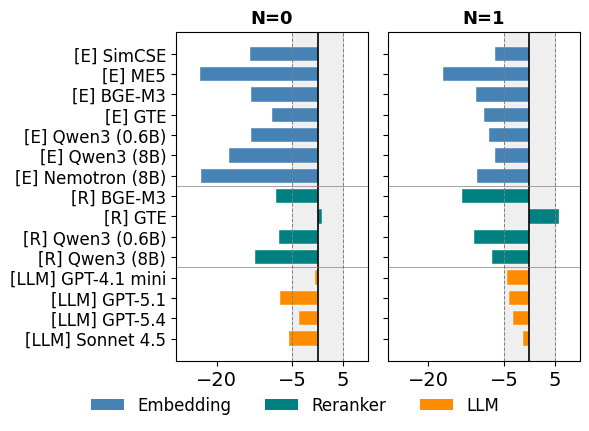

In [18]:
# NER impact figure — inlined for direct figsize/legend/xlim tweaks
from matplotlib.patches import Patch

figsize    = (6, 5.0)
xlim       = xlim_B
color_map  = color_map_B
type_labels = type_labels_B
p_band     = 5
colors     = [color_map[t] for t in type_labels]

fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
titles    = ["N=0", "N=1"]
data_list = [n0_B, n1_B]
y_pos     = np.arange(len(methods_B))

for ax, data, title in zip(axes, data_list, titles):
    ax.barh(y_pos, data, color=colors, height=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='-')
    ax.axvspan(-p_band, p_band, color='gray', alpha=0.12, zorder=0)
    ax.axvline( p_band, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(-p_band, color='gray', linewidth=0.7, linestyle='--')
    ax.set_title(title, fontsize=FS["title"], fontweight='bold')
    ax.tick_params(labelsize=14)
    ax.set_xlim(*xlim)

    n_emb = type_labels.count("Embedding")
    n_rnk = type_labels.count("Reranker")
    ax.axhline(n_emb - 0.5,         color='gray', linewidth=0.5, linestyle='-')
    ax.axhline(n_emb + n_rnk - 0.5, color='gray', linewidth=0.5, linestyle='-')
    ax.set_xticks([-20,-5,5])

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(methods_B, fontsize=12)
axes[0].invert_yaxis()

#fig.supxlabel("Avg. relative decrease (%)", fontsize=14, y=0.22)

legend_elements = [Patch(facecolor=color_map[t], label=t) for t in color_map]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.13))

fig.tight_layout(rect=[0, 0.18, 1, 1])
fig.savefig(f"{dir_figs}/ner_impact_summary.pdf", bbox_inches='tight', dpi=300)
plt.show()


# Multi-shot ICL

==================== ndcg ====================
                        N=3        N=5
[E] SimCSE        -2.623190  -0.708439
[E] ME5           -4.890618  -5.118371
[E] BGE-M3        -2.647885  -2.799135
[E] GTE           -2.171912  -1.620571
[E] Qwen3 (0.6B)  -1.577078   0.446079
[E] Qwen3 (8B)     1.772071   2.943267
[E] Nemotron (8B)  1.278558   2.943286
[R] BGE-M3        -8.818461 -14.616555
[R] GTE            7.126840   8.620348
[R] Qwen3 (0.6B)  -2.152704  -2.955501
[R] Qwen3 (8B)     0.852150   1.093162


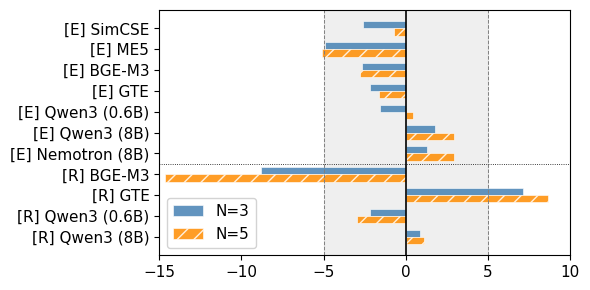

==================== recall ====================
                        N=3        N=5
[E] SimCSE        -1.655629  -0.678521
[E] ME5           -3.355232  -3.726997
[E] BGE-M3        -1.392823  -1.885036
[E] GTE           -1.011236  -1.144114
[E] Qwen3 (0.6B)  -1.699843   0.044573
[E] Qwen3 (8B)     0.932712   1.556676
[E] Nemotron (8B)  1.030043   2.462527
[R] BGE-M3        -6.727535 -10.872642
[R] GTE            5.842019   5.962060
[R] Qwen3 (0.6B)   0.293399  -1.483749
[R] Qwen3 (8B)     0.813376   0.460526


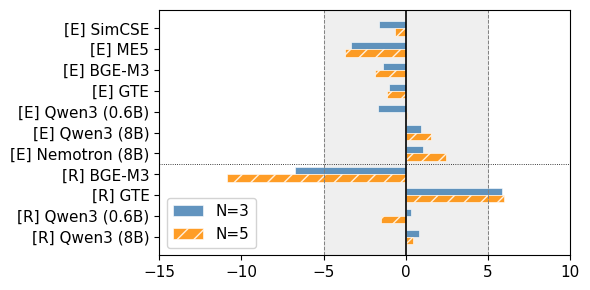

In [19]:
# Multi-shot ICL: relative improvement of separate vs concat — inlined
for score_name, dict_table in ddict_table.items():
    print("=="*10, score_name, "=="*10)
    d_ = defaultdict(dict)
    for p, d in dict_table.items():
        if p in [f"{a}_{n_icl}-sample" for n_icl in N_icl[1:] for a in ["concat", "separate"]]:
            p1 = p.split("_")[0]
            p2 = p.split("_")[1].split("-")[0]
            df_ = loader.reindex(d["mean"]).mean(axis=1)
            df_ = df_.loc[[i for i in df_.index if "LLM" not in i]]
            d_[p1][f"N={p2}"] = df_

    df_imp = pd.DataFrame(d_["concat"]) / pd.DataFrame(d_["separate"]) - 1
    df_imp = df_imp.loc[model_names_selected_encoder] * 100
    print(df_imp)

    # Plot (only ndcg is saved as main figure)
    figsize = (6, 3)
    p_band  = 5
    colors  = ['steelblue', 'darkorange']
    hatches = ['', '//']

    fig, ax = plt.subplots(figsize=figsize)

    n_models   = len(df_imp)
    n_cols     = len(df_imp.columns)
    bar_height = 0.35
    y_pos      = np.arange(n_models)

    for j, (col, hatch, color) in enumerate(zip(df_imp.columns, hatches, colors)):
        offset = (j - (n_cols - 1) / 2) * bar_height
        vals   = df_imp[col].values
        ax.barh(y_pos + offset, vals, height=bar_height,
                color=color, hatch=hatch, edgecolor='white', linewidth=0.5,
                label=col, alpha=0.85)

    ax.axvline(0, color='black', linewidth=1.2, linestyle='-')
    ax.axvline( p_band, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(-p_band, color='gray', linewidth=0.7, linestyle='--')
    ax.axvspan(-p_band, p_band, color='gray', alpha=0.12, zorder=0)

    n_enc = sum(1 for m in df_imp.index if '[E]' in m)
    if 0 < n_enc < n_models:
        ax.axhline(n_enc - 0.5, color='black', linewidth=0.6, linestyle=':')

    ax.set_xlim(-3 * p_band, 2 * p_band)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_imp.index, fontsize=FS["tick"])
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=FS["tick"])
    #ax.set_xlabel("Relative improvement over Separate (%)", fontsize=FS["axis"])
    ax.legend(loc='lower left', fontsize=FS["legend"], frameon=True, framealpha=0.85)

    fig.tight_layout()
    fig.savefig(f"{dir_figs}/concat_vs_separate_{score_name}.pdf",
                bbox_inches='tight', dpi=300)
    plt.show()


In [20]:
# Appendix: Concat nDCG@5 in broad cold-start (N=3, N=5) — all methods incl. baselines
score_name = "ndcg"
dict_table = ddict_table[score_name]
print("=="*10, f"Cold-start N=3, N=5 ({score_name})", "=="*10)
d_ = defaultdict(dict)
for p, d in dict_table.items():
    if p in ["concat_3-sample", "concat_5-sample"]:
        df_tex, df_color = loader.to_tex(d, p_value, model_name_base)
        d_["tex"][p]   = loader.reindex(df_tex)
        d_["color"][p] = loader.reindex(df_color)

# Some LLMs may be missing for a given N; keep only rows we actually have.
available = [m for m in model_names_all if all(m in d_["tex"][p].index for p in d_["tex"])]
df_tex   = pd.concat(d_["tex"],   axis=1).loc[available]
display(df_tex)
df_color = pd.concat(d_["color"], axis=1).loc[available]
df_tex   = df_color + df_tex
df_tex   = loader.to_two_columns(df_tex)
print(df_tex.to_latex(escape=False))

==================== Cold-start N=3, N=5 (ndcg) ====================


concat_3-sample                           \
                                         ML-1M                      Job   
[E] SimCSE                             $0.618$                  $0.502$   
[E] ModernBERT         $0.465^{\triangledown}$                  $0.492$   
[E] RoBERTa            $0.553^{\triangledown}$                  $0.473$   
[E] ME5                                $0.612$              $0.570^{*}$   
[E] BGE-M3                             $0.617$              $0.588^{*}$   
[E] GTE                                $0.624$              $0.579^{*}$   
[E] Qwen3 (0.6B)                       $0.656$                  $0.547$   
[E] Qwen3 (8B)                     $0.662^{*}$              $0.583^{*}$   
[E] Nemotron (8B)         $\textbf{0.690}^{*}$     $\textbf{0.605}^{*}$   
[R] BM25                               $0.584$  $\underline{0.595}^{*}$   
[R] BGE-M3             $0.564^{\triangledown}$                  $0.476$   
[R] GTE                $0.465^{\triangledown}$                  $0.476$   
[R] Qwen3 (0.6B)                       $0.595$                  $0.528$   
[R] Qwen3 (8B)         $\underline{0.678}^{*}$              $0.590^{*}$   
[LLM] Llama3.3 (70B)   $0.560^{\triangledown}$  $0.426^{\triangledown}$   
[LLM] Qwen3-235B-A22B  $0.511^{\triangledown}$  $0.462^{\triangledown}$   
[LLM] GPT-4.1 mini                     $0.589$                  $0.517$   
[LLM] GPT-5.1                          $0.599$              $0.562^{*}$   
[LLM] GPT-5.4                          $0.593$              $0.562^{*}$   
[LLM] Sonnet 4.5                       $0.607$              $0.580^{*}$   

                                                                         \
                                         Music                    Movie   
[E] SimCSE                             $0.528$                  $0.570$   
[E] ModernBERT         $0.352^{\triangledown}$  $0.378^{\triangledown}$   
[E] RoBERTa            $0.376^{\triangledown}$  $0.494^{\triangledown}$   
[E] ME5                $0.458^{\triangledown}$  $0.518^{\triangledown}$   
[E] BGE-M3                             $0.531$                  $0.567$   
[E] GTE                            $0.618^{*}$                  $0.613$   
[E] Qwen3 (0.6B)                   $0.605^{*}$              $0.618^{*}$   
[E] Qwen3 (8B)                     $0.640^{*}$              $0.671^{*}$   
[E] Nemotron (8B)      $\underline{0.715}^{*}$     $\textbf{0.689}^{*}$   
[R] BM25                               $0.506$  $0.460^{\triangledown}$   
[R] BGE-M3                             $0.492$  $0.453^{\triangledown}$   
[R] GTE                                $0.525$  $0.471^{\triangledown}$   
[R] Qwen3 (0.6B)                       $0.505$                  $0.542$   
[R] Qwen3 (8B)            $\textbf{0.725}^{*}$                  $0.584$   
[LLM] Llama3.3 (70B)                   $0.546$                  $0.546$   
[LLM] Qwen3-235B-A22B              $0.599^{*}$                  $0.546$   
[LLM] GPT-4.1 mini                 $0.612^{*}$                  $0.590$   
[LLM] GPT-5.1                      $0.689^{*}$              $0.674^{*}$   
[LLM] GPT-5.4                      $0.710^{*}$  $\underline{0.677}^{*}$   
[LLM] Sonnet 4.5                   $0.666^{*}$              $0.644^{*}$   

                                                                         \
                                          Toys                   Sports   
[E] SimCSE                             $0.640$                  $0.655$   
[E] ModernBERT         $0.459^{\triangledown}$  $0.412^{\triangledown}$   
[E] RoBERTa            $0.533^{\triangledown}$  $0.484^{\triangledown}$   
[E] ME5                                $0.631$                  $0.666$   
[E] BGE-M3                             $0.611$                  $0.622$   
[E] GTE                                $0.660$              $0.696^{*}$   
[E] Qwen3 (0.6B)                       $0.664$              $0.700^{*}$   
[E] Qwen3 (8B)         $\underline{0.690}^{*}$  $\unde

\begin{tabular}{lllllllllllll}
\toprule
 & \multicolumn{6}{r}{concat_3-sample} & \multicolumn{6}{r}{concat_5-sample} \\
 & ML-1M & Job & Music & Movie & Toys & Sports & ML-1M & Job & Music & Movie & Toys & Sports \\
\midrule
E &  SimCSE & $0.618$ & $0.502$ & $0.528$ & $0.570$ & $0.640$ & $0.655$ & $0.609$ & $0.498$ & $0.551$ & $0.605$ & $0.652$ & $0.671$ \\
E &  ModernBERT & \cellcolor{nshigh}$0.465^{\triangledown}$ & $0.492$ & \cellcolor{nshigh}$0.352^{\triangledown}$ & \cellcolor{nshigh}$0.378^{\triangledown}$ & \cellcolor{nshigh}$0.459^{\triangledown}$ & \cellcolor{nshigh}$0.412^{\triangledown}$ & \cellcolor{nshigh}$0.433^{\triangledown}$ & \cellcolor{nslow}$0.475$ & \cellcolor{nshigh}$0.332^{\triangledown}$ & \cellcolor{nshigh}$0.383^{\triangledown}$ & \cellcolor{nshigh}$0.454^{\triangledown}$ & \cellcolor{nshigh}$0.416^{\triangledown}$ \\
E &  RoBERTa & \cellcolor{nmiddle}$0.553^{\triangledown}$ & \cellcolor{nlow}$0.473$ & \cellcolor{nshigh}$0.376^{\triangledown}$ & \cellcolor{nmi

In [21]:
df = ddict_table["ndcg"]["concat_1-sample"]["mean"]
df = df.loc[[i for i in df.index if "default" in i]]
df_rank = loader.compute_rank(df)
v = df_rank.loc["[LLM] Sonnet 4.5:::default"].values.astype(int)
print(v, np.mean(1 / v))

[12  2  5  9 12  9] 0.1814814814814815


In [22]:
# Appendix: Separate nDCG@5 in broad cold-start (N=3, N=5) — all methods incl. baselines
score_name = "ndcg"
dict_table = ddict_table[score_name]
print("=="*10, f"Cold-start N=3, N=5 ({score_name})", "=="*10)
d_ = defaultdict(dict)
for p, d in dict_table.items():
    if p in ["separate_3-sample", "separate_5-sample"]:
        df_tex, df_color = loader.to_tex(d, p_value, model_name_base)
        d_["tex"][p]   = loader.reindex(df_tex)
        d_["color"][p] = loader.reindex(df_color)

# Some LLMs may be missing for a given N; keep only rows we actually have.
available = [m for m in model_names_all if all(m in d_["tex"][p].index for p in d_["tex"])]
df_tex   = pd.concat(d_["tex"],   axis=1).loc[available]
display(df_tex)
df_color = pd.concat(d_["color"], axis=1).loc[available]
df_tex   = df_color + df_tex
df_tex   = loader.to_two_columns(df_tex)
print(df_tex.to_latex(escape=False))

==================== Cold-start N=3, N=5 (ndcg) ====================


separate_3-sample                           \
                                         ML-1M                      Job   
[E] SimCSE                 $\underline{0.670}$                  $0.512$   
[E] ModernBERT         $0.530^{\triangledown}$  $0.459^{\triangledown}$   
[E] RoBERTa            $0.568^{\triangledown}$  $0.449^{\triangledown}$   
[E] ME5                                $0.649$  $\underline{0.585}^{*}$   
[E] BGE-M3                             $0.654$              $0.558^{*}$   
[E] GTE                                $0.640$              $0.578^{*}$   
[E] Qwen3 (0.6B)                       $0.663$              $0.549^{*}$   
[E] Qwen3 (8B)                         $0.665$              $0.571^{*}$   
[E] Nemotron (8B)             $\textbf{0.700}$              $0.575^{*}$   
[R] BM25               $0.619^{\triangledown}$     $\textbf{0.597}^{*}$   
[R] BGE-M3             $0.608^{\triangledown}$                  $0.526$   
[R] GTE                $0.342^{\triangledown}$  $0.431^{\triangledown}$   
[R] Qwen3 (0.6B)                       $0.653$                  $0.548$   
[R] Qwen3 (8B)                         $0.669$              $0.561^{*}$   
[LLM] Llama3.3 (70B)   $0.560^{\triangledown}$  $0.426^{\triangledown}$   
[LLM] Qwen3-235B-A22B  $0.511^{\triangledown}$  $0.462^{\triangledown}$   
[LLM] GPT-4.1 mini     $0.589^{\triangledown}$                  $0.517$   
[LLM] GPT-5.1          $0.599^{\triangledown}$              $0.562^{*}$   
[LLM] GPT-5.4          $0.593^{\triangledown}$              $0.562^{*}$   
[LLM] Sonnet 4.5       $0.607^{\triangledown}$              $0.580^{*}$   

                                                                         \
                                         Music                    Movie   
[E] SimCSE                             $0.529$                  $0.579$   
[E] ModernBERT         $0.431^{\triangledown}$  $0.452^{\triangledown}$   
[E] RoBERTa            $0.441^{\triangledown}$  $0.537^{\triangledown}$   
[E] ME5                                $0.526$                  $0.541$   
[E] BGE-M3                             $0.554$                  $0.592$   
[E] GTE                            $0.644^{*}$              $0.645^{*}$   
[E] Qwen3 (0.6B)                   $0.614^{*}$              $0.636^{*}$   
[E] Qwen3 (8B)                     $0.618^{*}$              $0.659^{*}$   
[E] Nemotron (8B)      $\underline{0.711}^{*}$     $\textbf{0.681}^{*}$   
[R] BM25                               $0.514$  $0.468^{\triangledown}$   
[R] BGE-M3                             $0.553$  $0.488^{\triangledown}$   
[R] GTE                                $0.560$  $0.462^{\triangledown}$   
[R] Qwen3 (0.6B)                       $0.529$                  $0.533$   
[R] Qwen3 (8B)            $\textbf{0.731}^{*}$                  $0.563$   
[LLM] Llama3.3 (70B)                   $0.546$                  $0.546$   
[LLM] Qwen3-235B-A22B              $0.599^{*}$                  $0.546$   
[LLM] GPT-4.1 mini                 $0.612^{*}$                  $0.590$   
[LLM] GPT-5.1                      $0.689^{*}$              $0.674^{*}$   
[LLM] GPT-5.4                      $0.710^{*}$  $\underline{0.677}^{*}$   
[LLM] Sonnet 4.5                   $0.666^{*}$              $0.644^{*}$   

                                                                         \
                                          Toys                   Sports   
[E] SimCSE                             $0.654$                  $0.663$   
[E] ModernBERT         $0.533^{\triangledown}$  $0.481^{\triangledown}$   
[E] RoBERTa            $0.572^{\triangledown}$  $0.540^{\triangledown}$   
[E] ME5                                $0.643$                  $0.687$   
[E] BGE-M3                             $0.625$                  $0.650$   
[E] GTE                                $0.665$              $0.703^{*}$   
[E] Qwen3 (0.6B)                       $0.675$     $\textbf{0.714}^{*}$   
[E] Qwen3 (8B)             $\underline{0.682}$      

\begin{tabular}{lllllllllllll}
\toprule
 & \multicolumn{6}{r}{separate_3-sample} & \multicolumn{6}{r}{separate_5-sample} \\
 & ML-1M & Job & Music & Movie & Toys & Sports & ML-1M & Job & Music & Movie & Toys & Sports \\
\midrule
E &  SimCSE & $\underline{0.670}$ & $0.512$ & $0.529$ & $0.579$ & $0.654$ & $0.663$ & $0.659$ & $0.487$ & $0.538$ & $0.595$ & $0.643$ & $0.688$ \\
E &  ModernBERT & \cellcolor{nshigh}$0.530^{\triangledown}$ & \cellcolor{nmiddle}$0.459^{\triangledown}$ & \cellcolor{nhigh}$0.431^{\triangledown}$ & \cellcolor{nshigh}$0.452^{\triangledown}$ & \cellcolor{nhigh}$0.533^{\triangledown}$ & \cellcolor{nshigh}$0.481^{\triangledown}$ & \cellcolor{nhigh}$0.559^{\triangledown}$ & \cellcolor{nlow}$0.448$ & \cellcolor{nshigh}$0.422^{\triangledown}$ & \cellcolor{nhigh}$0.491^{\triangledown}$ & \cellcolor{nmiddle}$0.560^{\triangledown}$ & \cellcolor{nshigh}$0.503^{\triangledown}$ \\
E &  RoBERTa & \cellcolor{nhigh}$0.568^{\triangledown}$ & \cellcolor{nmiddle}$0.449^{\triangledow

# Overall ranking

In [23]:
dd = defaultdict(dict)
for ner_name, ddict_t in {"original": ddict_table, "NER": ddict_table_NER}.items():
    d_ = defaultdict(dict)
    for p, d in ddict_t["ndcg"].items():
        if p in ["profile"] + [f"concat_{n_icl}-sample" for n_icl in N_icl]:
            df    = d["mean"]
            df    = df.loc[[i for i in df.index if "default" in i]]
            s_mrr = loader.compute_mrr(loader.compute_rank(df))
            d_["mrr"][p] = loader.reindex(s_mrr)

    df_mrr  = pd.DataFrame(d_["mrr"])
    df_tex  = loader.add_bold(df_mrr)
    df_tex  = df_tex + " (" + loader.compute_rank(df_mrr).map(lambda s: f"{int(s)}") + ")"

    df_color = loader.add_color((df_mrr - 0.1) * 1.1)

    dd["score"][ner_name] = "$" + df_tex + "$"
    dd["color"][ner_name] = df_color

df_tex   = pd.concat(dd["score"], axis=1).loc[model_names_selected]
display(df_tex)
df_color = pd.concat(dd["color"], axis=1).loc[model_names_selected]
df_tex   = df_color + df_tex
df_tex   = loader.to_two_columns(df_tex)
print(df_tex.to_latex(escape=False))

original                           \
                                    profile          concat_1-sample   
[E] SimCSE                     $0.074 (16)$              $0.171 (7)$   
[E] ME5                         $0.208 (6)$             $0.134 (10)$   
[E] BGE-M3                      $0.175 (7)$             $0.096 (13)$   
[E] GTE                        $0.098 (11)$              $0.167 (9)$   
[E] Qwen3 (0.6B)               $0.116 (10)$              $0.170 (8)$   
[E] Qwen3 (8B)                  $0.344 (4)$              $0.382 (3)$   
[E] Nemotron (8B)   $\underline{0.500} (2)$     $\textbf{0.700} (1)$   
[R] BGE-M3                      $0.407 (3)$             $0.075 (15)$   
[R] GTE                        $0.075 (15)$             $0.066 (16)$   
[R] Qwen3 (0.6B)               $0.090 (13)$             $0.130 (11)$   
[R] Qwen3 (8B)         $\textbf{0.567} (1)$              $0.207 (5)$   
[LLM] GPT-4.1 mini             $0.085 (14)$             $0.096 (12)$   
[LLM] GPT-5.1                   $0.159 (8)$              $0.299 (4)$   
[LLM] GPT-5.4                   $0.151 (9)$  $\underline{0.407} (2)$   
[LLM] Sonnet 4.5                $0.237 (5)$              $0.181 (6)$   

                                                                      \
                            concat_3-sample          concat_5-sample   
[E] SimCSE                     $0.111 (11)$             $0.093 (12)$   
[E] ME5                        $0.104 (12)$             $0.095 (11)$   
[E] BGE-M3                     $0.120 (10)$              $0.099 (9)$   
[E] GTE                         $0.180 (6)$              $0.197 (5)$   
[E] Qwen3 (0.6B)                $0.200 (5)$              $0.180 (8)$   
[E] Qwen3 (8B)                  $0.325 (3)$  $\underline{0.315} (2)$   
[E] Nemotron (8B)      $\textbf{0.917} (1)$     $\textbf{1.000} (1)$   
[R] BGE-M3                     $0.061 (18)$             $0.058 (18)$   
[R] GTE                        $0.069 (16)$             $0.063 (17)$   
[R] Qwen3 (0.6B)               $0.094 (13)$             $0.098 (10)$   
[R] Qwen3 (8B)      $\underline{0.363} (2)$              $0.291 (4)$   
[LLM] GPT-4.1 mini             $0.091 (14)$             $0.089 (13)$   
[LLM] GPT-5.1                   $0.166 (7)$              $0.194 (6)$   
[LLM] GPT-5.4                   $0.260 (4)$              $0.309 (3)$   
[LLM] Sonnet 4.5                $0.155 (8)$              $0.188 (7)$   

                                        NER                           \
                                    profile          concat_1-sample   
[E] SimCSE                     $0.068 (16)$             $0.115 (10)$   
[E] ME5                        $0.068 (17)$             $0.067 (16)$   
[E] BGE-M3                     $0.101 (11)$             $0.081 (15)$   
[E] GTE                         $0.122 (9)$              $0.152 (8)$   
[E] Qwen3 (0.6B)                $0.139 (8)$              $0.329 (4)$   
[E] Qwen3 (8B)                 $0.117 (10)$  $\underline{0.396} (2)$   
[E] Nemotron (8B)              $0.074 (14)$              $0.192 (7)$   
[R] BGE-M3          $\underline{0.447} (2)$             $0.062 (18)$   
[R] GTE                         $0.303 (4)$             $0.094 (13)$   
[R] Qwen3 (0.6B)               $0.097 (12)$             $0.096 (12)$   
[R] Qwen3 (8B)         $\textbf{0.537} (1)$              $0.250 (5)$   
[LLM] GPT-4.1 mini              $0.206 (7)$              $0.133 (9)$   
[LLM] GPT-5.1                   $0.270 (6)$              $0.239 (6)$   
[LLM] GPT-5.4                   $0.426 (3)$     $\textbf{0.653} (1)$   
[LLM] Sonnet 4.5                $0.289 (5)$              $0.371 (3)$   

                                                                      
                            concat_3-sample          concat_5-sample  
[E] SimCSE                     $0.093 (13)$             $0.099 (11)$  
[E] ME5                        $0.059 (18)$             $0.063 (17)$  
[E] BGE-M3                     $0.077 (16)$             $0.074 (15)$  
[E] G

\begin{tabular}{lllllllll}
\toprule
 & \multicolumn{4}{r}{original} & \multicolumn{4}{r}{NER} \\
 & profile & concat_1-sample & concat_3-sample & concat_5-sample & profile & concat_1-sample & concat_3-sample & concat_5-sample \\
\midrule
E &  SimCSE & \cellcolor{nslow}$0.074 (16)$ & \cellcolor{pslow}$0.171 (7)$ & $0.111 (11)$ & $0.093 (12)$ & \cellcolor{nslow}$0.068 (16)$ & $0.115 (10)$ & $0.093 (13)$ & $0.099 (11)$ \\
E &  ME5 & \cellcolor{plow}$0.208 (6)$ & $0.134 (10)$ & $0.104 (12)$ & $0.095 (11)$ & \cellcolor{nslow}$0.068 (17)$ & \cellcolor{nslow}$0.067 (16)$ & \cellcolor{nslow}$0.059 (18)$ & \cellcolor{nslow}$0.063 (17)$ \\
E &  BGE-M3 & \cellcolor{pslow}$0.175 (7)$ & $0.096 (13)$ & $0.120 (10)$ & $0.099 (9)$ & $0.101 (11)$ & $0.081 (15)$ & \cellcolor{nslow}$0.077 (16)$ & \cellcolor{nslow}$0.074 (15)$ \\
E &  GTE & $0.098 (11)$ & \cellcolor{pslow}$0.167 (9)$ & \cellcolor{pslow}$0.180 (6)$ & \cellcolor{plow}$0.197 (5)$ & $0.122 (9)$ & \cellcolor{pslow}$0.152 (8)$ & $0.118 (10)$ & 

## MRR heatmap

In [24]:
figsize_C = (5.5, 4.0)
vmin_C = 0.0
vmax_C = 0.65

In [25]:
# MRR matrix: model × condition (same values as Table 6), for original and NER text
methods_C, cols_C, original_C, ner_C = extract_mrr_heatmap(
    ddict_table, ddict_table_NER, model_names_selected, loader, N_icl,
)
print(f"{'Model':<30}", "  ".join(f"{c:>6}" for c in cols_C))
for m, row_o, row_n in zip(methods_C, original_C, ner_C):
    print(f"{m:<30}", "  ".join(f"{v:>6.3f}" for v in row_o), " | NER:", "  ".join(f"{v:>6.3f}" for v in row_n))

Model                             N=0     N=1     N=3     N=5
[E] SimCSE                      0.074   0.171   0.111   0.093  | NER:  0.068   0.115   0.093   0.099
[E] ME5                         0.208   0.134   0.104   0.095  | NER:  0.068   0.067   0.059   0.063
[E] BGE-M3                      0.175   0.096   0.120   0.099  | NER:  0.101   0.081   0.077   0.074
[E] GTE                         0.098   0.167   0.180   0.197  | NER:  0.122   0.152   0.118   0.118
[E] Qwen3 (0.6B)                0.116   0.170   0.200   0.180  | NER:  0.139   0.329   0.237   0.186
[E] Qwen3 (8B)                  0.344   0.382   0.325   0.315  | NER:  0.117   0.396   0.485   0.372
[E] Nemotron (8B)               0.500   0.700   0.917   1.000  | NER:  0.074   0.192   0.201   0.214
[R] BGE-M3                      0.407   0.075   0.061   0.058  | NER:  0.447   0.062   0.065   0.060
[R] GTE                         0.075   0.066   0.069   0.063  | NER:  0.303   0.094   0.080   0.070
[R] Qwen3 (0.6B)             

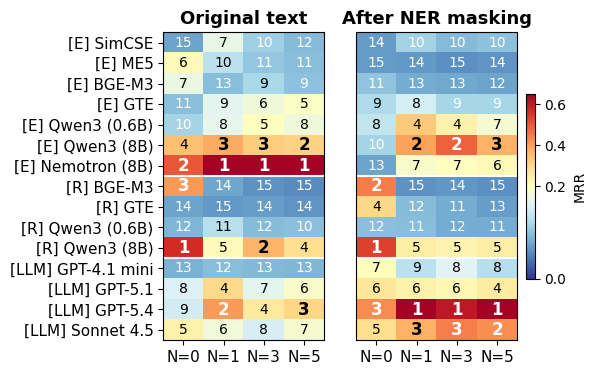

In [26]:
# MRR heatmap (original vs NER)
from matplotlib.colors import TwoSlopeNorm

figsize = figsize_C
vmin    = vmin_C
vmax    = vmax_C
vcenter = 0.2

def _compute_ranks(arr):
    ranks = np.zeros_like(arr, dtype=int)
    for j in range(arr.shape[1]):
        order = np.argsort(-arr[:, j])
        for rank, idx in enumerate(order, 1):
            ranks[idx, j] = rank
    return ranks

fig, axes = plt.subplots(1, 2, figsize=figsize)
titles    = ["Original text", "After NER masking"]
data_list = [original_C, ner_C]
norm      = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

for ax, data, title in zip(axes, data_list, titles):
    ranks = _compute_ranks(data)
    im    = ax.imshow(data, cmap='RdYlBu_r', aspect='auto', norm=norm)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            r     = ranks[i, j]
            fw    = 'bold' if r <= 3 else 'normal'
            fs    = FS["annot"] if r <= 3 else FS["annot_small"]
            color = 'white' if (data[i, j] > 0.40 or data[i, j] < 0.12) else 'black'
            ax.text(j, i, str(r), ha='center', va='center',
                    fontsize=fs, fontweight=fw, color=color)
    ax.set_xticks(range(len(cols_C)))
    ax.set_xticklabels(cols_C, fontsize=FS["tick"])
    ax.set_title(title, fontsize=FS["title"], fontweight='bold')
    ax.tick_params(labelsize=FS["tick"])
    for sep in [6.5, 10.5]:  # separate Embedding | Reranker | LLM blocks
        ax.axhline(sep, color='white', linewidth=1.5)

axes[0].set_yticks(range(len(methods_C)))
axes[0].set_yticklabels(methods_C, fontsize=FS["tick"])
axes[1].set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.6, label='MRR', pad=0.02)
fig.savefig(f"{dir_figs}/mrr_heatmap.pdf", bbox_inches='tight', dpi=300)
plt.show()

# L=50

In [27]:
candidate_size_long = 50
at_K_long = 10
N_icl_long = [1]

scorer_long = Scorer(candidate_size=candidate_size_long, at_K=at_K_long)
loader_long = Loader(scorer_long, dir_workspace, version_exp, N_icl=N_icl_long, flag_replace_NER=False)
dict_data_long, ddict_log_long = load_with_cache(
    scorer_long, loader_long, data_names, model_names_emb, model_names_reranker, model_names_llm
)

======================================== ML-1M ========================================


Models: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.95it/s]


======================================== Job ========================================


Models: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 13.77it/s]


======================================== Music ========================================


...

======================================== Sports ========================================


Models: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 21.95it/s]

======================================== Total computation cost in USD ========================================


,ML-1M,Job,Music,Movie,Toys,Sports,Sum
[LLM] GPT-5.1,2.0,29.5,5.0,4.6,6.1,5.8,53.1
[LLM] GPT-5.4,3.8,58.6,9.9,9.1,12.1,11.4,104.9
[LLM] Sonnet 4.5,6.7,86.7,15.8,15.2,19.3,18.5,162.2


\begin{tabular}{llllllll}
\toprule
 & ML-1M & Job & Music & Movie & Toys & Sports & Sum \\
\midrule
[LLM] GPT-5.1 & $2.0$ & $29.5$ & $5.0$ & $4.6$ & $6.1$ & $5.8$ & $53.1$ \\
[LLM] GPT-5.4 & $3.8$ & $58.6$ & $9.9$ & $9.1$ & $12.1$ & $11.4$ & $104.9$ \\
[LLM] Sonnet 4.5 & $6.7$ & $86.7$ & $15.8$ & $15.2$ & $19.3$ & $18.5$ & $162.2$ \\
\bottomrule
\end{tabular}



In [28]:
dict_stat_long   = loader_long.add_statistics(dict_data_long, model_name_base)
ddict_table_long = {s: loader_long.reshape_data(dict_stat_long, s) for s in ["ndcg", "recall"]}

Hypothesis Testing: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.99it/s]


In [29]:
# L=50 main-text model subset (Section 4.3).
model_names_L50_main = [
    '[E] SimCSE',
    '[E] ME5',
    '[E] BGE-M3',
    '[E] GTE',
    '[E] Qwen3 (0.6B)',
    '[E] Qwen3 (8B)',
    '[E] Nemotron (8B)',
    "[R] BM25",
    '[R] BGE-M3',
    '[R] GTE',
    '[R] Qwen3 (0.6B)',
    '[R] Qwen3 (8B)',
    '[LLM] GPT-5.1',
    '[LLM] GPT-5.4',
    '[LLM] Sonnet 4.5',
]
model_names_selected = model_names_selected_encoder + model_names_selected_llm

for score_name, dict_table in ddict_table_long.items():
    print("=="*10, f"L=50 main body ({score_name})", "=="*10)
    d_tex = {}
    d_color = {}

    for p, d in dict_table.items():
        if p not in ["profile", "separate_1-sample"]:
            continue
        p_label = p.replace("separate_", "").replace("sample", "shot")

        # Per-dataset scores with significance marks
        df_tex_ds, df_color_ds = loader_long.to_tex(d, p_value, model_name_base)
        df_tex_ds_full   = loader_long.reindex(df_tex_ds)
        df_color_ds_full = loader_long.reindex(df_color_ds)
        avail = [m for m in model_names_L50_main if m in df_tex_ds_full.index]
        df_tex_ds   = df_tex_ds_full.loc[avail]
        df_color_ds = df_color_ds_full.loc[avail]

        # MRR and Rank recomputed within the subset
        df_mean_all = d["mean"].loc[[i for i in d["mean"].index if "default" in i]]
        avail_idx   = [f"{m}:::default" for m in avail]
        df_mean     = df_mean_all.loc[avail_idx]
        df_ranks    = loader_long.compute_rank(df_mean)
        s_mrr       = loader_long.compute_mrr(df_ranks)
        s_mrr.index = [i.split(":::")[0] for i in s_mrr.index]

        df_mrr_fmt = loader_long.add_bold(pd.DataFrame({"MRR": s_mrr}))
        s_mrr_rank = s_mrr.rank(ascending=False, method="min").astype(int)

        s_mrr_tex  = "$" + df_mrr_fmt["MRR"] + "$"
        s_rank_tex = s_mrr_rank.map(lambda r: f"${r}$")

        s_base_rank = s_mrr_rank.mean()
        df_mrr_imp  = pd.DataFrame({"MRR": ((s_base_rank - s_mrr_rank) / s_base_rank) * 0.2})
        s_mrr_color = loader_long.add_color(df_mrr_imp)["MRR"]

        d_tex[p_label] = pd.concat([
            df_tex_ds,
            s_mrr_tex.rename("MRR"),
            s_rank_tex.rename("Rank"),
        ], axis=1)
        d_color[p_label] = pd.concat([
            df_color_ds,
            s_mrr_color.rename("MRR"),
            pd.Series("", index=df_tex_ds.index, name="Rank"),
        ], axis=1)

    df_tex = pd.concat(d_tex, axis=1)
    display(df_tex)
    df_color = pd.concat(d_color, axis=1)
    df_final = df_color + df_tex
    df_final = loader_long.to_two_columns(df_final)
    print(df_final.to_latex(escape=False))

==================== L=50 main body (ndcg) ====================


profile                           \
                                     ML-1M           Job (with-exp)   
[E] SimCSE                         $0.124$                  $0.268$   
[E] ME5                            $0.129$                  $0.303$   
[E] BGE-M3                         $0.131$                  $0.278$   
[E] GTE                            $0.139$  $0.211^{\triangledown}$   
[E] Qwen3 (0.6B)                   $0.123$              $0.340^{*}$   
[E] Qwen3 (8B)                     $0.141$              $0.395^{*}$   
[E] Nemotron (8B)                  $0.146$              $0.368^{*}$   
[R] BM25                           $0.112$                  $0.254$   
[R] BGE-M3                         $0.127$              $0.350^{*}$   
[R] GTE                            $0.119$                  $0.250$   
[R] Qwen3 (0.6B)                   $0.106$              $0.324^{*}$   
[R] Qwen3 (8B)                     $0.140$     $\textbf{0.445}^{*}$   
[LLM] GPT-5.1         $\textbf{0.204}^{*}$  $\underline{0.397}^{*}$   
[LLM] GPT-5.4                  $0.182^{*}$              $0.380^{*}$   
[LLM] Sonnet 4.5   $\underline{0.188}^{*}$              $0.365^{*}$   

                                                                       \
                              Job (no-exp)                  MRR  Rank   
[E] SimCSE                         $0.187$              $0.082$  $13$   
[E] ME5                        $0.261^{*}$              $0.126$   $8$   
[E] BGE-M3                     $0.225^{*}$              $0.105$  $10$   
[E] GTE                            $0.201$              $0.098$  $11$   
[E] Qwen3 (0.6B)               $0.258^{*}$              $0.117$   $9$   
[E] Qwen3 (8B)                 $0.295^{*}$              $0.261$   $3$   
[E] Nemotron (8B)              $0.285^{*}$              $0.217$   $7$   
[R] BM25                           $0.149$              $0.072$  $15$   
[R] BGE-M3         $\underline{0.297}^{*}$              $0.248$   $5$   
[R] GTE                            $0.200$              $0.075$  $14$   
[R] Qwen3 (0.6B)                   $0.216$              $0.090$  $12$   
[R] Qwen3 (8B)        $\textbf{0.315}^{*}$     $\textbf{0.722}$   $1$   
[LLM] GPT-5.1                  $0.297^{*}$  $\underline{0.611}$   $2$   
[LLM] GPT-5.4                  $0.243^{*}$              $0.236$   $6$   
[LLM] Sonnet 4.5                   $0.225$              $0.259$   $4$   

                                    1-shot                           \
                                     ML-1M                      Job   
[E] SimCSE                         $0.291$                  $0.357$   
[E] ME5                            $0.300$                  $0.362$   
[E] BGE-M3                         $0.277$                  $0.359$   
[E] GTE                            $0.282$                  $0.381$   
[E] Qwen3 (0.6B)                   $0.273$                  $0.377$   
[E] Qwen3 (8B)         $\underline{0.311}$              $0.402^{*}$   
[E] Nemotron (8B)         $\textbf{0.322}$                  $0.386$   
[R] BM25                           $0.276$                  $0.369$   
[R] BGE-M3                         $0.274$  $0.266^{\triangledown}$   
[R] GTE            $0.168^{\triangledown}$  $0.228^{\triangledown}$   
[R] Qwen3 (0.6B)                   $0.304$                  $0.373$   
[R] Qwen3 (8B)                     $0.311$                  $0.373$   
[LLM] GPT-5.1                      $0.282$     $\textbf{0.432}^{*}$   
[LLM] GPT-5.4                      $0.275$  $\underline{0.407}^{*}$   
[LLM] Sonnet 4.5                   $0.279$                  $0.396$   

                                                                     \
                                     Music                    Movie   
[E] SimCSE                         $0.365$                  $0.338$   
[E] ME5                            $0.366$                  $0.345$   
[E] BGE-M3                         $0.337$                  $0.314$   
[E] GTE               

\begin{tabular}{llllllllllllll}
\toprule
 & \multicolumn{5}{r}{profile} & \multicolumn{8}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & MRR & Rank & ML-1M & Job & Music & Movie & Toys & Sports & MRR & Rank \\
\midrule
E &  SimCSE & $0.124$ & $0.268$ & $0.187$ & \cellcolor{nmiddle}$0.082$ & $13$ & $0.291$ & $0.357$ & $0.365$ & $0.338$ & $0.365$ & $0.363$ & \cellcolor{nlow}$0.118$ & $11$ \\
E &  ME5 & $0.129$ & \cellcolor{plow}$0.303$ & \cellcolor{pshigh}$0.261^{*}$ & $0.126$ & $8$ & $0.300$ & $0.362$ & $0.366$ & $0.345$ & $0.358$ & \cellcolor{nslow}$0.348$ & $0.127$ & $9$ \\
E &  BGE-M3 & \cellcolor{pslow}$0.131$ & $0.278$ & \cellcolor{pmiddle}$0.225^{*}$ & \cellcolor{nslow}$0.105$ & $10$ & \cellcolor{nslow}$0.277$ & $0.359$ & \cellcolor{nlow}$0.337$ & \cellcolor{nlow}$0.314$ & \cellcolor{nlow}$0.335$ & \cellcolor{nlow}$0.327^{\triangledown}$ & \cellcolor{nlow}$0.086$ & $12$ \\
E &  GTE & \cellcolor{plow}$0.139$ & \cellcolor{nshigh}$0.211^{\triangledown}$ & \cellcolor{pslow}$

profile                           \
                                     ML-1M           Job (with-exp)   
[E] SimCSE                         $0.224$                  $0.384$   
[E] ME5                            $0.232$              $0.450^{*}$   
[E] BGE-M3                         $0.232$                  $0.400$   
[E] GTE                            $0.249$                  $0.331$   
[E] Qwen3 (0.6B)                   $0.221$              $0.456^{*}$   
[E] Qwen3 (8B)                     $0.239$  $\underline{0.505}^{*}$   
[E] Nemotron (8B)                  $0.251$              $0.476^{*}$   
[R] BM25                           $0.199$                  $0.366$   
[R] BGE-M3                         $0.220$              $0.496^{*}$   
[R] GTE                            $0.218$                  $0.358$   
[R] Qwen3 (0.6B)                   $0.194$                  $0.415$   
[R] Qwen3 (8B)                     $0.234$     $\textbf{0.573}^{*}$   
[LLM] GPT-5.1         $\textbf{0.321}^{*}$              $0.460^{*}$   
[LLM] GPT-5.4                  $0.300^{*}$                  $0.432$   
[LLM] Sonnet 4.5   $\underline{0.312}^{*}$                  $0.439$   

                                                                       \
                              Job (no-exp)                  MRR  Rank   
[E] SimCSE                         $0.294$              $0.089$  $12$   
[E] ME5                        $0.392^{*}$              $0.200$   $7$   
[E] BGE-M3                         $0.337$              $0.114$  $11$   
[E] GTE                            $0.301$              $0.122$  $10$   
[E] Qwen3 (0.6B)               $0.358^{*}$              $0.133$   $9$   
[E] Qwen3 (8B)                 $0.383^{*}$              $0.306$   $4$   
[E] Nemotron (8B)              $0.371^{*}$              $0.233$   $5$   
[R] BM25                           $0.253$              $0.072$  $15$   
[R] BGE-M3            $\textbf{0.459}^{*}$  $\underline{0.472}$   $2$   
[R] GTE                            $0.313$              $0.086$  $13$   
[R] Qwen3 (0.6B)                   $0.298$              $0.086$  $14$   
[R] Qwen3 (8B)     $\underline{0.425}^{*}$     $\textbf{0.548}$   $1$   
[LLM] GPT-5.1                  $0.361^{*}$              $0.456$   $3$   
[LLM] GPT-5.4                      $0.284$              $0.174$   $8$   
[LLM] Sonnet 4.5                   $0.273$              $0.232$   $6$   

                                    1-shot                           \
                                     ML-1M                      Job   
[E] SimCSE                         $0.455$                  $0.459$   
[E] ME5                            $0.450$                  $0.494$   
[E] BGE-M3                         $0.432$                  $0.473$   
[E] GTE                            $0.441$                  $0.479$   
[E] Qwen3 (0.6B)                   $0.430$                  $0.482$   
[E] Qwen3 (8B)                     $0.473$  $\underline{0.506}^{*}$   
[E] Nemotron (8B)         $\textbf{0.486}$                  $0.486$   
[R] BM25                           $0.438$                  $0.489$   
[R] BGE-M3                         $0.431$  $0.381^{\triangledown}$   
[R] GTE            $0.272^{\triangledown}$  $0.315^{\triangledown}$   
[R] Qwen3 (0.6B)                   $0.466$                  $0.469$   
[R] Qwen3 (8B)         $\underline{0.479}$                  $0.484$   
[LLM] GPT-5.1                      $0.425$         $\textbf{0.508}$   
[LLM] GPT-5.4                      $0.429$                  $0.475$   
[LLM] Sonnet 4.5                   $0.428$                  $0.481$   

                                                                     \
                                     Music                    Movie   
[E] SimCSE                         $0.484$                  $0.457$   
[E] ME5                            $0.501$                  $0.480$   
[E] BGE-M3                         $0.442$                  $0.434$   
[E] GTE               

\begin{tabular}{llllllllllllll}
\toprule
 & \multicolumn{5}{r}{profile} & \multicolumn{8}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & MRR & Rank & ML-1M & Job & Music & Movie & Toys & Sports & MRR & Rank \\
\midrule
E &  SimCSE & $0.224$ & $0.384$ & $0.294$ & \cellcolor{nlow}$0.089$ & $12$ & $0.455$ & $0.459$ & $0.484$ & $0.457$ & $0.459$ & $0.491$ & \cellcolor{nslow}$0.144$ & $10$ \\
E &  ME5 & $0.232$ & \cellcolor{pmiddle}$0.450^{*}$ & \cellcolor{pshigh}$0.392^{*}$ & $0.200$ & $7$ & $0.450$ & \cellcolor{pslow}$0.494$ & $0.501$ & \cellcolor{pslow}$0.480$ & $0.448$ & $0.480$ & $0.182$ & $8$ \\
E &  BGE-M3 & $0.232$ & $0.400$ & \cellcolor{plow}$0.337$ & \cellcolor{nlow}$0.114$ & $11$ & \cellcolor{nlow}$0.432$ & $0.473$ & \cellcolor{nlow}$0.442$ & \cellcolor{nlow}$0.434$ & \cellcolor{nmiddle}$0.407^{\triangledown}$ & \cellcolor{nlow}$0.444^{\triangledown}$ & \cellcolor{nmiddle}$0.090$ & $13$ \\
E &  GTE & \cellcolor{plow}$0.249$ & \cellcolor{nmiddle}$0.331$ & $0.301$ & \cell

In [30]:
# L=50 appendix table (tab:scalability_L50_full) — all methods, MRR recomputed within subset.
model_names_L50 = model_names_all
model_names_L50_idx = [f"{m}:::default" for m in model_names_L50]

dict_table_L50 = ddict_table_long["ndcg"]
d_tex_out   = {}
d_color_out = {}

for p, d in dict_table_L50.items():
    if p not in ["profile", "separate_1-sample"]:
        continue
    p_label = p.replace("separate_", "").replace("sample", "shot")

    # Full per-dataset score table (all indices), then filter to available L=50 rows.
    df_tex_ds, df_color_ds = loader_long.to_tex(d, p_value, model_name_base)
    df_tex_ds_full   = loader_long.reindex(df_tex_ds)
    df_color_ds_full = loader_long.reindex(df_color_ds)
    avail = [m for m in model_names_L50 if m in df_tex_ds_full.index]
    df_tex_ds   = df_tex_ds_full.loc[avail]
    df_color_ds = df_color_ds_full.loc[avail]

    # MRR and Rank recomputed within the available subset
    df_mean_all = d["mean"].loc[[i for i in d["mean"].index if "default" in i]]
    avail_idx   = [f"{m}:::default" for m in avail]
    df_mean     = df_mean_all.loc[avail_idx]
    df_ranks    = loader_long.compute_rank(df_mean)
    s_mrr       = loader_long.compute_mrr(df_ranks)
    s_mrr.index = [i.split(":::")[0] for i in s_mrr.index]

    df_mrr_fmt  = loader_long.add_bold(pd.DataFrame({"MRR": s_mrr}))
    s_mrr_rank  = s_mrr.rank(ascending=False, method="min").astype(int)
    s_mrr_tex   = "$" + df_mrr_fmt["MRR"] + "$"
    s_rank_tex  = s_mrr_rank.map(lambda r: f"${r}$")

    s_base_rank = s_mrr_rank.mean()
    df_mrr_imp  = pd.DataFrame({"MRR": ((s_base_rank - s_mrr_rank) / s_base_rank) * 0.2})
    s_mrr_color = loader_long.add_color(df_mrr_imp)["MRR"]

    d_tex_out[p_label]   = pd.concat(
        [df_tex_ds,   s_mrr_tex.rename("MRR"),  s_rank_tex.rename("Rank")],  axis=1)
    d_color_out[p_label] = pd.concat(
        [df_color_ds, s_mrr_color.rename("MRR"), pd.Series("", index=df_tex_ds.index, name="Rank")],
        axis=1)

# Align rows across all conditions (union of available models, in model_names_L50 order)
all_available = []
for p_label in d_tex_out:
    for m in d_tex_out[p_label].index:
        if m not in all_available:
            all_available.append(m)
all_available = [m for m in model_names_L50 if m in all_available]

for k in d_tex_out:
    d_tex_out[k]   = d_tex_out[k].reindex(all_available).fillna("")
    d_color_out[k] = d_color_out[k].reindex(all_available).fillna("")

df_tex   = pd.concat(d_tex_out,   axis=1)
df_color = pd.concat(d_color_out, axis=1)
df_final = df_color + df_tex
df_final = loader_long.to_two_columns(df_final)
df_final.index = [i.split(":::")[0] for i in df_final.index]
display(df_final)
print("\n[LaTeX rows for tab:scalability_L50_full]")
print(df_final.to_latex(escape=False))

profile  \
                                                        ML-1M   
E &  SimCSE                                           $0.124$   
E &  ModernBERT                                       $0.126$   
E &  RoBERTa                         \cellcolor{nhigh}$0.104$   
E &  ME5                                              $0.129$   
E &  BGE-M3                          \cellcolor{pslow}$0.131$   
E &  GTE                              \cellcolor{plow}$0.139$   
E &  Qwen3 (0.6B)                                     $0.123$   
E &  Qwen3 (8B)                       \cellcolor{plow}$0.141$   
E &  Nemotron (8B)                 \cellcolor{pmiddle}$0.146$   
R &  BM25                             \cellcolor{nlow}$0.112$   
R &  BGE-M3                                           $0.127$   
R &  GTE                             \cellcolor{nslow}$0.119$   
R &  Qwen3 (0.6B)                  \cellcolor{nmiddle}$0.106$   
R &  Qwen3 (8B)                       \cellcolor{plow}$0.140$   
LLM &  GPT-5.1         \cellcolor{pshigh}$\textbf{0.204}^{*}$   
LLM &  GPT-5.4                  \cellcolor{pshigh}$0.182^{*}$   
LLM &  Sonnet 4.5   \cellcolor{pshigh}$\underline{0.188}^{*}$   

                                                               \
                                               Job (with-exp)   
E &  SimCSE                                           $0.268$   
E &  ModernBERT     \cellcolor{nshigh}$0.089^{\triangledown}$   
E &  RoBERTa        \cellcolor{nshigh}$0.083^{\triangledown}$   
E &  ME5                              \cellcolor{plow}$0.303$   
E &  BGE-M3                                           $0.278$   
E &  GTE            \cellcolor{nshigh}$0.211^{\triangledown}$   
E &  Qwen3 (0.6B)                \cellcolor{phigh}$0.340^{*}$   
E &  Qwen3 (8B)                 \cellcolor{pshigh}$0.395^{*}$   
E &  Nemotron (8B)              \cellcolor{pshigh}$0.368^{*}$   
R &  BM25                             \cellcolor{nlow}$0.254$   
R &  BGE-M3                     \cellcolor{pshigh}$0.350^{*}$   
R &  GTE                              \cellcolor{nlow}$0.250$   
R &  Qwen3 (0.6B)                \cellcolor{phigh}$0.324^{*}$   
R &  Qwen3 (8B)        \cellcolor{pshigh}$\textbf{0.445}^{*}$   
LLM &  GPT-5.1      \cellcolor{pshigh}$\underline{0.397}^{*}$   
LLM &  GPT-5.4                  \cellcolor{pshigh}$0.380^{*}$   
LLM &  Sonnet 4.5               \cellcolor{pshigh}$0.365^{*}$   

                                                               \
                                                 Job (no-exp)   
E &  SimCSE                                           $0.187$   
E &  ModernBERT     \cellcolor{nshigh}$0.088^{\triangledown}$   
E &  RoBERTa        \cellcolor{nshigh}$0.080^{\triangledown}$   
E &  ME5                        \cellcolor{pshigh}$0.261^{*}$   
E &  BGE-M3                    \cellcolor{pmiddle}$0.225^{*}$   
E &  GTE                             \cellcolor{pslow}$0.201$   
E &  Qwen3 (0.6B)               \cellcolor{pshigh}$0.258^{*}$   
E &  Qwen3 (8B)                 \cellcolor{pshigh}$0.295^{*}$   
E &  Nemotron (8B)              \cellcolor{pshigh}$0.285^{*}$   
R &  BM25                           \cellcolor{nshigh}$0.149$   
R &  BGE-M3         \cellcolor{pshigh}$\underline{0.297}^{*}$   
R &  GTE                             \cellcolor{pslow}$0.200$   
R &  Qwen3 (0.6B)                  \cellcolor{pmiddle}$0.216$   
R &  Qwen3 (8B)        \cellcolor{pshigh}$\textbf{0.315}^{*}$   
LLM &  GPT-5.1                  \cellcolor{pshigh}$0.297^{*}$   
LLM &  GPT-5.4                   \cellcolor{phigh}$0.243^{*}$   
LLM &  Sonnet 4.5                    \cellcolor{phigh}$0.225$   

                                                                  \
                                                       MRR  Rank   
E &  SimCSE                        \cellcolor{nlow}$0.079$  $13$   
E &  ModernBERT                 \cellcolor{nmiddle}$0.072$  $15$   
E &  RoBERTa                      \cellcolor{nhigh}$0.059$  $17$   
E &  M


[LaTeX rows for tab:scalability_L50_full]
\begin{tabular}{llllllllllllll}
\toprule
 & \multicolumn{5}{r}{profile} & \multicolumn{8}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & MRR & Rank & ML-1M & Job & Music & Movie & Toys & Sports & MRR & Rank \\
\midrule
E &  SimCSE & $0.124$ & $0.268$ & $0.187$ & \cellcolor{nlow}$0.079$ & $13$ & $0.291$ & $0.357$ & $0.365$ & $0.338$ & $0.365$ & $0.363$ & \cellcolor{nslow}$0.118$ & $11$ \\
E &  ModernBERT & $0.126$ & \cellcolor{nshigh}$0.089^{\triangledown}$ & \cellcolor{nshigh}$0.088^{\triangledown}$ & \cellcolor{nmiddle}$0.072$ & $15$ & \cellcolor{nshigh}$0.220^{\triangledown}$ & \cellcolor{nshigh}$0.217^{\triangledown}$ & \cellcolor{nshigh}$0.233^{\triangledown}$ & \cellcolor{nshigh}$0.261^{\triangledown}$ & \cellcolor{nhigh}$0.308^{\triangledown}$ & \cellcolor{nshigh}$0.247^{\triangledown}$ & \cellcolor{nhigh}$0.061$ & $17$ \\
E &  RoBERTa & \cellcolor{nhigh}$0.104$ & \cellcolor{nshigh}$0.083^{\triangledown}$ & \cellcolor{nshigh}$0

# Cost

In [31]:
# total API cost in USD (original + NER runs combined)
l = []
for ddict_log_ in [ddict_log, ddict_log_NER]:
    d_cost = {}
    for data_name, dict_log in ddict_log_.items():
        d_cost[data_name] = {
            m: np.sum([v.loc["fee (USD)"] for v in d_log.values()])
            for m, d_log in dict_log.items()
        }
    df = pd.DataFrame(d_cost)
    df["Sum"] = df.sum(axis=1)
    l.append(df)

df_cost = l[0] + l[1]
df_cost.index = [i.replace("[LLM] ", "") for i in df_cost.index]
display(df_cost.round(1))
print(df_cost.map(lambda s: f"${s:.1f}$").to_latex(escape=False))

,ML-1M,Job,Music,Movie,Toys,Sports,Sum
Llama3.3 (70B),1.7,15.4,5.2,5.2,5.5,5.0,38.1
Qwen3-235B-A22B,0.5,4.9,1.7,1.7,1.8,1.6,12.1
GPT-4.1 mini,0.9,8.6,3.0,3.0,3.1,2.8,21.5
GPT-5.1,3.9,28.3,10.0,10.0,10.5,9.6,72.3
GPT-5.4,6.5,54.9,19.1,19.0,20.0,18.2,137.7
Sonnet 4.5,13.7,86.8,34.6,36.6,35.4,31.2,238.4


\begin{tabular}{llllllll}
\toprule
 & ML-1M & Job & Music & Movie & Toys & Sports & Sum \\
\midrule
Llama3.3 (70B) & $1.7$ & $15.4$ & $5.2$ & $5.2$ & $5.5$ & $5.0$ & $38.1$ \\
Qwen3-235B-A22B & $0.5$ & $4.9$ & $1.7$ & $1.7$ & $1.8$ & $1.6$ & $12.1$ \\
GPT-4.1 mini & $0.9$ & $8.6$ & $3.0$ & $3.0$ & $3.1$ & $2.8$ & $21.5$ \\
GPT-5.1 & $3.9$ & $28.3$ & $10.0$ & $10.0$ & $10.5$ & $9.6$ & $72.3$ \\
GPT-5.4 & $6.5$ & $54.9$ & $19.1$ & $19.0$ & $20.0$ & $18.2$ & $137.7$ \\
Sonnet 4.5 & $13.7$ & $86.8$ & $34.6$ & $36.6$ & $35.4$ & $31.2$ & $238.4$ \\
\bottomrule
\end{tabular}



In [32]:
# total inference time in hours
l = []
for ddict_log_ in [ddict_log, ddict_log_NER]:
    d_time = {}
    for data_name, dict_log in ddict_log_.items():
        d_time[data_name] = {
            m: np.sum([v.loc["time (sec)"] for v in d_log.values()])
            for m, d_log in dict_log.items()
        }
    df = pd.DataFrame(d_time) / 3600
    df["Sum"] = df.sum(axis=1)
    l.append(df)

df_time = l[0] + l[1]
df_time.index = [i.replace("[LLM] ", "") for i in df_time.index]
display(df_time.round(1))
print(df_time.map(lambda s: f"${s:.1f}$").to_latex(escape=False))

,ML-1M,Job,Music,Movie,Toys,Sports,Sum
Llama3.3 (70B),1.2,1.0,0.5,0.6,0.5,0.5,4.4
Qwen3-235B-A22B,1.2,1.9,1.1,1.0,1.0,1.1,7.3
GPT-4.1 mini,1.0,1.5,0.8,0.8,0.8,0.8,5.8
GPT-5.1,1.6,2.5,1.3,1.3,1.3,1.3,9.3
GPT-5.4,1.6,2.1,1.2,1.2,1.3,1.3,8.7
Sonnet 4.5,4.6,7.6,4.7,5.2,4.6,4.0,30.6


\begin{tabular}{llllllll}
\toprule
 & ML-1M & Job & Music & Movie & Toys & Sports & Sum \\
\midrule
Llama3.3 (70B) & $1.2$ & $1.0$ & $0.5$ & $0.6$ & $0.5$ & $0.5$ & $4.4$ \\
Qwen3-235B-A22B & $1.2$ & $1.9$ & $1.1$ & $1.0$ & $1.0$ & $1.1$ & $7.3$ \\
GPT-4.1 mini & $1.0$ & $1.5$ & $0.8$ & $0.8$ & $0.8$ & $0.8$ & $5.8$ \\
GPT-5.1 & $1.6$ & $2.5$ & $1.3$ & $1.3$ & $1.3$ & $1.3$ & $9.3$ \\
GPT-5.4 & $1.6$ & $2.1$ & $1.2$ & $1.2$ & $1.3$ & $1.3$ & $8.7$ \\
Sonnet 4.5 & $4.6$ & $7.6$ & $4.7$ & $5.2$ & $4.6$ & $4.0$ & $30.6$ \\
\bottomrule
\end{tabular}



## LLM inference cost

In [33]:
# LLM cost by setting; sums across all text_types.
def _cost_df(ddict_log_in, llms):
    d_cost = {}
    for data_name, dict_log in ddict_log_in.items():
        d_cost[data_name] = {}
        for m in llms:
            d_log_ = dict_log.get(m, {})
            d_cost[data_name][m] = float(np.sum(
                [v.loc["fee (USD)"] for v in d_log_.values()]
            ))
    df = pd.DataFrame(d_cost).reindex(llms)
    df = df.reindex(sorted(df.columns), axis=1)
    return df


def _strip_llm_prefix(df):
    df = df.copy()
    df.index = [i.replace("[LLM] ", "") for i in df.index]
    return df


def _with_totals(df, label):
    df = df.copy()
    df["Sum"] = df.sum(axis=1)
    total_row = df.sum(axis=0).to_frame(name="Total").T
    df = pd.concat([df, total_row], axis=0)
    df.index.name = label
    return df


def _print_cost_table(df, label, latex_label):
    print("==" * 10, label, "==" * 10)
    display(df.round(2))
    df_tex = df.map(lambda s: f"${s:.2f}$")
    print(f"[LaTeX rows for {latex_label}]")
    print(df_tex.to_latex(escape=False))
    print()


llms_paper = [loader.rename_for_paper(m) for m in model_names_llm]

df_cost_orig = _with_totals(_strip_llm_prefix(_cost_df(ddict_log,      llms_paper)), "Original (L=10)")
df_cost_ner  = _with_totals(_strip_llm_prefix(_cost_df(ddict_log_NER,  llms_paper)), "NER (L=10)")
df_cost_l50  = _with_totals(_strip_llm_prefix(_cost_df(ddict_log_long, llms_paper)), "Original (L=50)")

_print_cost_table(df_cost_orig, "LLM cost USD — L=10, original",    "tab:llm_cost_l10_orig")
_print_cost_table(df_cost_ner,  "LLM cost USD — L=10, NER-masked",  "tab:llm_cost_l10_ner")
_print_cost_table(df_cost_l50,  "LLM cost USD — L=50, original",    "tab:llm_cost_l50")

==================== LLM cost USD — L=10, original ====================


,Job,ML-1M,Movie,Music,Sports,Toys,Sum
Original (L=10),,,,,,,
Llama3.3 (70B),7.69,0.86,2.60,2.59,2.51,2.75,19.00
Qwen3-235B-A22B,2.44,0.26,0.83,0.84,0.81,0.89,6.06
GPT-4.1 mini,4.30,0.46,1.47,1.47,1.42,1.56,10.68
GPT-5.1,14.05,1.94,4.96,4.96,4.81,5.23,35.97
GPT-5.4,27.30,3.22,9.43,9.42,9.12,9.97,68.47
Sonnet 4.5,42.71,7.02,17.20,15.54,15.02,16.72,114.22
Total,98.49,13.78,36.49,34.81,33.71,37.13,254.40


[LaTeX rows for tab:llm_cost_l10_orig]
\begin{tabular}{llllllll}
\toprule
 & Job & ML-1M & Movie & Music & Sports & Toys & Sum \\
Original (L=10) &  &  &  &  &  &  &  \\
\midrule
Llama3.3 (70B) & $7.69$ & $0.86$ & $2.60$ & $2.59$ & $2.51$ & $2.75$ & $19.00$ \\
Qwen3-235B-A22B & $2.44$ & $0.26$ & $0.83$ & $0.84$ & $0.81$ & $0.89$ & $6.06$ \\
GPT-4.1 mini & $4.30$ & $0.46$ & $1.47$ & $1.47$ & $1.42$ & $1.56$ & $10.68$ \\
GPT-5.1 & $14.05$ & $1.94$ & $4.96$ & $4.96$ & $4.81$ & $5.23$ & $35.97$ \\
GPT-5.4 & $27.30$ & $3.22$ & $9.43$ & $9.42$ & $9.12$ & $9.97$ & $68.47$ \\
Sonnet 4.5 & $42.71$ & $7.02$ & $17.20$ & $15.54$ & $15.02$ & $16.72$ & $114.22$ \\
Total & $98.49$ & $13.78$ & $36.49$ & $34.81$ & $33.71$ & $37.13$ & $254.40$ \\
\bottomrule
\end{tabular}


==================== LLM cost USD — L=10, NER-masked ====================


,Job,ML-1M,Movie,Music,Sports,Toys,Sum
NER (L=10),,,,,,,
Llama3.3 (70B),7.74,0.80,2.63,2.64,2.49,2.76,19.05
Qwen3-235B-A22B,2.43,0.25,0.83,0.84,0.79,0.87,6.02
GPT-4.1 mini,4.35,0.46,1.49,1.51,1.41,1.57,10.79
GPT-5.1,14.21,1.95,5.04,5.08,4.79,5.26,36.34
GPT-5.4,27.61,3.23,9.59,9.66,9.08,10.03,69.20
Sonnet 4.5,44.11,6.72,19.43,19.05,16.22,18.66,124.19
Total,100.46,13.42,39.02,38.77,34.77,39.16,265.59


[LaTeX rows for tab:llm_cost_l10_ner]
\begin{tabular}{llllllll}
\toprule
 & Job & ML-1M & Movie & Music & Sports & Toys & Sum \\
NER (L=10) &  &  &  &  &  &  &  \\
\midrule
Llama3.3 (70B) & $7.74$ & $0.80$ & $2.63$ & $2.64$ & $2.49$ & $2.76$ & $19.05$ \\
Qwen3-235B-A22B & $2.43$ & $0.25$ & $0.83$ & $0.84$ & $0.79$ & $0.87$ & $6.02$ \\
GPT-4.1 mini & $4.35$ & $0.46$ & $1.49$ & $1.51$ & $1.41$ & $1.57$ & $10.79$ \\
GPT-5.1 & $14.21$ & $1.95$ & $5.04$ & $5.08$ & $4.79$ & $5.26$ & $36.34$ \\
GPT-5.4 & $27.61$ & $3.23$ & $9.59$ & $9.66$ & $9.08$ & $10.03$ & $69.20$ \\
Sonnet 4.5 & $44.11$ & $6.72$ & $19.43$ & $19.05$ & $16.22$ & $18.66$ & $124.19$ \\
Total & $100.46$ & $13.42$ & $39.02$ & $38.77$ & $34.77$ & $39.16$ & $265.59$ \\
\bottomrule
\end{tabular}


==================== LLM cost USD — L=50, original ====================


,Job,ML-1M,Movie,Music,Sports,Toys,Sum
Original (L=50),,,,,,,
Llama3.3 (70B),0.00,0.00,0.00,0.00,0.00,0.00,0.00
Qwen3-235B-A22B,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GPT-4.1 mini,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GPT-5.1,29.54,2.02,4.60,5.02,5.79,6.13,53.10
GPT-5.4,58.65,3.76,9.06,9.89,11.44,12.12,104.90
Sonnet 4.5,86.71,6.71,15.19,15.79,18.49,19.32,162.20
Total,174.90,12.49,28.85,30.70,35.71,37.57,320.21


[LaTeX rows for tab:llm_cost_l50]
\begin{tabular}{llllllll}
\toprule
 & Job & ML-1M & Movie & Music & Sports & Toys & Sum \\
Original (L=50) &  &  &  &  &  &  &  \\
\midrule
Llama3.3 (70B) & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ \\
Qwen3-235B-A22B & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ \\
GPT-4.1 mini & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ & $0.00$ \\
GPT-5.1 & $29.54$ & $2.02$ & $4.60$ & $5.02$ & $5.79$ & $6.13$ & $53.10$ \\
GPT-5.4 & $58.65$ & $3.76$ & $9.06$ & $9.89$ & $11.44$ & $12.12$ & $104.90$ \\
Sonnet 4.5 & $86.71$ & $6.71$ & $15.19$ & $15.79$ & $18.49$ & $19.32$ & $162.20$ \\
Total & $174.90$ & $12.49$ & $28.85$ & $30.70$ & $35.71$ & $37.57$ & $320.21$ \\
\bottomrule
\end{tabular}




### Total across all three tables

In [34]:
# Combine the three cost matrices (drop the Sum/Total helpers first so we
# re-compute them once on the summed matrix).
core = lambda df: df.drop(index="Total", errors="ignore").drop(columns="Sum", errors="ignore")
cost_core_all = (
    core(df_cost_orig).add(core(df_cost_ner), fill_value=0.0)
                      .add(core(df_cost_l50), fill_value=0.0)
)

llms_paper_disp = [m.replace("[LLM] ", "") for m in llms_paper]
df_cost_all = _with_totals(cost_core_all.reindex(llms_paper_disp), "All settings")

_print_cost_table(
    df_cost_all,
    "LLM cost USD — grand total (L=10 orig + L=10 NER + L=50)",
    "tab:llm_cost_all",
)

grand_total = float(cost_core_all.values.sum())
per_setting = {
    "L=10 (original)": float(core(df_cost_orig).values.sum()),
    "L=10 (NER)":      float(core(df_cost_ner ).values.sum()),
    "L=50 (original)": float(core(df_cost_l50 ).values.sum()),
}
print("Per-setting totals (USD):")
for k, v in per_setting.items():
    print(f"  {k:<18s}: ${v:,.1f}")
print(f"  {'GRAND TOTAL':<18s}: ${grand_total:,.2f}")

==================== LLM cost USD — grand total (L=10 orig + L=10 NER + L=50) ====================


,Job,ML-1M,Movie,Music,Sports,Toys,Sum
All settings,,,,,,,
Llama3.3 (70B),15.43,1.66,5.22,5.24,5.00,5.51,38.05
Qwen3-235B-A22B,4.87,0.52,1.66,1.68,1.61,1.76,12.09
GPT-4.1 mini,8.65,0.93,2.96,2.97,2.84,3.12,21.47
GPT-5.1,57.81,5.92,14.61,15.05,15.39,16.63,125.41
GPT-5.4,113.56,10.21,28.08,28.97,29.64,32.12,242.58
Sonnet 4.5,173.53,20.45,51.82,50.38,49.73,54.71,400.61
Total,373.84,39.68,104.36,104.28,104.19,113.85,840.21


[LaTeX rows for tab:llm_cost_all]
\begin{tabular}{llllllll}
\toprule
 & Job & ML-1M & Movie & Music & Sports & Toys & Sum \\
All settings &  &  &  &  &  &  &  \\
\midrule
Llama3.3 (70B) & $15.43$ & $1.66$ & $5.22$ & $5.24$ & $5.00$ & $5.51$ & $38.05$ \\
Qwen3-235B-A22B & $4.87$ & $0.52$ & $1.66$ & $1.68$ & $1.61$ & $1.76$ & $12.09$ \\
GPT-4.1 mini & $8.65$ & $0.93$ & $2.96$ & $2.97$ & $2.84$ & $3.12$ & $21.47$ \\
GPT-5.1 & $57.81$ & $5.92$ & $14.61$ & $15.05$ & $15.39$ & $16.63$ & $125.41$ \\
GPT-5.4 & $113.56$ & $10.21$ & $28.08$ & $28.97$ & $29.64$ & $32.12$ & $242.58$ \\
Sonnet 4.5 & $173.53$ & $20.45$ & $51.82$ & $50.38$ & $49.73$ & $54.71$ & $400.61$ \\
Total & $373.84$ & $39.68$ & $104.36$ & $104.28$ & $104.19$ & $113.85$ & $840.21$ \\
\bottomrule
\end{tabular}


Per-setting totals (USD):
  L=10 (original)   : $254.4
  L=10 (NER)        : $265.6
  L=50 (original)   : $320.2
  GRAND TOTAL       : $840.21


In [35]:
# Per-LLM total cost across all experiments (all settings + all datasets)
s_per_llm = cost_core_all.sum(axis=1).rename("Total (USD)")
s_per_llm.index.name = "LLM"
s_per_llm_sorted = s_per_llm.sort_values(ascending=False)

df_per_llm = s_per_llm_sorted.to_frame()
df_per_llm.loc["TOTAL"] = s_per_llm_sorted.sum()

print("=" * 50)
print("Per-LLM total cost — all experiments (USD)")
print("=" * 50)
display(df_per_llm.round(2))

# Breakdown by setting
per_setting_llm = {}
for label, df_s in [
    ("L=10 orig", df_cost_orig),
    ("L=10 NER",  df_cost_ner),
    ("L=50 orig", df_cost_l50),
]:
    per_setting_llm[label] = core(df_s).sum(axis=1)

df_setting_llm = pd.DataFrame(per_setting_llm).reindex(llms_paper_disp)
df_setting_llm["Sum"] = df_setting_llm.sum(axis=1)
df_setting_llm.index.name = "LLM"

print()
print("Per-LLM cost by setting (USD):")
display(df_setting_llm.round(2))

Per-LLM total cost — all experiments (USD)


,Total (USD)
LLM,
Sonnet 4.5,400.61
GPT-5.4,242.58
GPT-5.1,125.41
Llama3.3 (70B),38.05
GPT-4.1 mini,21.47
Qwen3-235B-A22B,12.09
TOTAL,840.21



Per-LLM cost by setting (USD):


,L=10 orig,L=10 NER,L=50 orig,Sum
LLM,,,,
Llama3.3 (70B),19.00,19.05,0.0,38.05
Qwen3-235B-A22B,6.06,6.02,0.0,12.09
GPT-4.1 mini,10.68,10.79,0.0,21.47
GPT-5.1,35.97,36.34,53.1,125.41
GPT-5.4,68.47,69.20,104.9,242.58
Sonnet 4.5,114.22,124.19,162.2,400.61


In [36]:
df_ = df_setting_llm.copy()
df_.loc["Total"] = df_.sum()
print(df_.map(lambda s : f"{s:.2f}").to_latex(escape=False))

\begin{tabular}{lllll}
\toprule
 & L=10 orig & L=10 NER & L=50 orig & Sum \\
LLM &  &  &  &  \\
\midrule
Llama3.3 (70B) & 19.00 & 19.05 & 0.00 & 38.05 \\
Qwen3-235B-A22B & 6.06 & 6.02 & 0.00 & 12.09 \\
GPT-4.1 mini & 10.68 & 10.79 & 0.00 & 21.47 \\
GPT-5.1 & 35.97 & 36.34 & 53.10 & 125.41 \\
GPT-5.4 & 68.47 & 69.20 & 104.90 & 242.58 \\
Sonnet 4.5 & 114.22 & 124.19 & 162.20 & 400.61 \\
Total & 254.40 & 265.59 & 320.21 & 840.21 \\
\bottomrule
\end{tabular}

